# **Stack Overflow Survey 2025**
## Investigating Columns


An identifying process of characteristics of a data set is carried out here as a begineer's step. The stack overflow survy 2025 was chosen as the sample data set. As known well, the SO Survey data is plentiful enough for glancing features of data analysis. First of all, I am starting investigating each column's features.

## Objectives

1. Identifying what each column is, namely the meaning and the role.
2. Grasping the features of given data. Data types and describing items, distribution style using visualization if needed.
3. Checking data status. Duplicated, isnull(), unit, range and others.
4. Viewing the data from many aspects using pandas APIs
5. Try to make correlations with related columns

## Preprocessing CSV file
0. The name of CSV file is "stackoverflowsurvey-2025.csv".
1. At first, opened the file with VS Code(Rainbow CSV) and checked the below items:
  - Coding is UTF8 with BOM
  - The 1st line
  - Delimiter
2. Secondly, read the file with read_csv() and saw the results of the below items:
  - df.shape
  - df.info()
  - df.dtypes
  - df.head()
  - df.tail()
3. Thirdly, opened the file with Excel to see the overall figures.
  - So many new lines in a cell, ignored it
  - Discovered 5 additional rows after 5195th row
  - Investigated the reason of 5 additional rows and found a big size(about 170K bytes) block of garbage string in a cell
4. Fourthly, more investigation on the reason of 5 additional rows
  - On VS Code, the big size block was found and there was no exceptional treatment
  - On Pandas, the big size block was truncated about 32K size
  - Conclusion: this big size can be ignored in further analysis

Import required Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<h2>Read Data</h2>
The data file was downloaded from stack overflow site, named as stackoverflow-survey-2025.csv and saved in local disk. The pandas.read_csv() was used to read in the file.

In [2]:
# Load the dataset local disk
file_path = "stackoverflow-survey-2025.csv"
df = pd.read_csv(file_path)
# Display the first few rows
#df.head()

C:\Users\IMST\AppData\Local\Temp\ipykernel_27912\611821233.py:3: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
print(df.shape)
df.info()
df.head()

(49191, 172)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [4]:
#check the big garbage block of which size is bigger than 170K bytes, the index number is 5195
print(len(df.iloc[5194]['AIOpen']))
repr(df.iloc[5194]['AIOpen'])

175026


'\'copying and pasting the word "no" hundreds more times. here we go! no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no 

In [5]:
#to get the column list
print(*df.columns, sep=',')


ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DatabaseChoice,DatabaseHaveWorkedWith,

In [6]:
#ResponseId, checking if serial numbers are missed
df['ResponseId']

0            1
1            2
2            3
3            4
4            5
         ...  
49186    49187
49187    49188
49188    49189
49189    49190
49190    49191
Name: ResponseId, Length: 49191, dtype: int64

In [8]:
#print the percentages of value_counts() result
def percentage(vc):
    width = vc.index.str.len().max() + 5
    #width = vc.index.map(len).max()
    sum = vc.sum()
    for i,v in vc.items():
        print(f"{i:{width}}{v:>7,}({v/sum*100:5.2f}%)")

In [9]:
#MainBranch, MC, Nominal
this = df['MainBranch']
print("This column is","'MainBranch', MC, Nominal")
print('dtype:',this.dtype)
print('isnull().sum(): ',this.isnull().sum())
vc = this.value_counts()
percentage(vc)

This column is 'MainBranch', MC, Nominal
dtype: object
isnull().sum():  0
I am a developer by profession                                                                  37,467(76.17%)
I am not primarily a developer, but I write code sometimes as part of my work/studies            4,894( 9.95%)
I am learning to code                                                                            2,585( 5.26%)
I code primarily as a hobby                                                                      1,924( 3.91%)
I used to be a developer by profession, but no longer am                                         1,325( 2.69%)
I work with developers or my work supports developers but am not a developer by profession         996( 2.02%)


In [10]:
#Age
this = df['Age']
print("This column is","'Age', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
percentage(vc)


This column is 'Age', MC, Nominal
dtype: object
isnull().sum(): 0
25-34 years old        16,519(33.58%)
35-44 years old        13,241(26.92%)
18-24 years old         9,210(18.72%)
45-54 years old         6,275(12.76%)
55-64 years old         2,626( 5.34%)
65 years or older         942( 1.91%)
Prefer not to say         378( 0.77%)


In [11]:
#EdLevel, MC, Nominal
this = df['EdLevel']
print("This column is","'EdLevel', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
percentage(vc)

This column is 'EdLevel', MC, Nominal
dtype: object
isnull().sum(): 1042
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                            20,278(42.12%)
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                         12,589(26.15%)
Some college/university study without earning a degree                                   6,182(12.84%)
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)       3,631( 7.54%)
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                           2,624( 5.45%)
Associate degree (A.A., A.S., etc.)                                                      1,562( 3.24%)
Other (please specify):                                                                    701( 1.46%)
Primary/elementary school                                                                  582( 1.21%)


In [12]:
#Employment, MC, Nominal
this = df['Employment']
print("This column is","'Employment', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
percentage(vc)

This column is 'Employment', MC, Nominal
dtype: object
isnull().sum(): 852
Employed                                                  33,750(69.82%)
Independent contractor, freelancer, or self-employed       6,708(13.88%)
Student                                                    4,428( 9.16%)
Not employed                                               2,227( 4.61%)
Retired                                                      708( 1.46%)
I prefer not to say                                          518( 1.07%)


In [33]:
#EmploymentAddl, MC, Multi-label
this = df['EmploymentAddl']
print("This column is","'EmploymentAddl', MC, Multi-label")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.str.split(';').explode().value_counts()
percentage(vc)

This column is 'EmploymentAddl', MC, Multi-label
dtype: object
isnull().sum(): 4316
None of the above                                                18,930(35.55%)
Caring for dependents (children, elderly, etc.)                   8,283(15.55%)
Engaged in paid work (20-29 hours per week)                       7,066(13.27%)
Volunteering (regularly)                                          5,504(10.34%)
Attending school (full-time)                                      4,428( 8.32%)
Engaged in paid work (less than 10 hours per week)                3,446( 6.47%)
Attending school (part-time)                                      2,747( 5.16%)
Engaged in paid work (10-19 hours per week)                       1,926( 3.62%)
Transitioning to retirement (gradually reducing work hours)         920( 1.73%)


This column is 'WorkExp', TE, Numeric
dtype: float64
isnull().sum(): 6298
WorkExp
10.0    2885
3.0     2613
5.0     2563
1.0     2453
2.0     2408
15.0    2226
4.0     2166
20.0    2094
8.0     1963
6.0     1810
7.0     1775
25.0    1649
12.0    1587
9.0     1221
30.0    1201
13.0    1176
11.0    1087
14.0     907
18.0     902
17.0     757
Name: count, dtype: int64


<Axes: xlabel='WorkExp'>

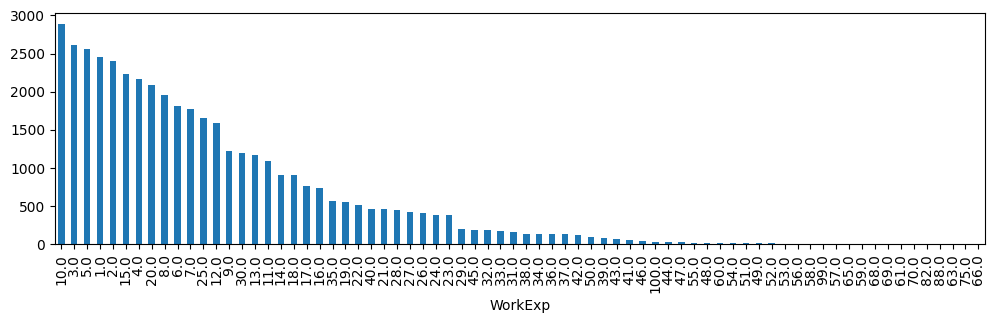

In [13]:
#WorkExp, TE, Numeric
this = df['WorkExp']
print("This column is","'WorkExp', TE, Numeric")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
print(vc.head(20))
vc.plot(kind='bar',figsize=(12,3))

<Axes: xlabel='WorkExp'>

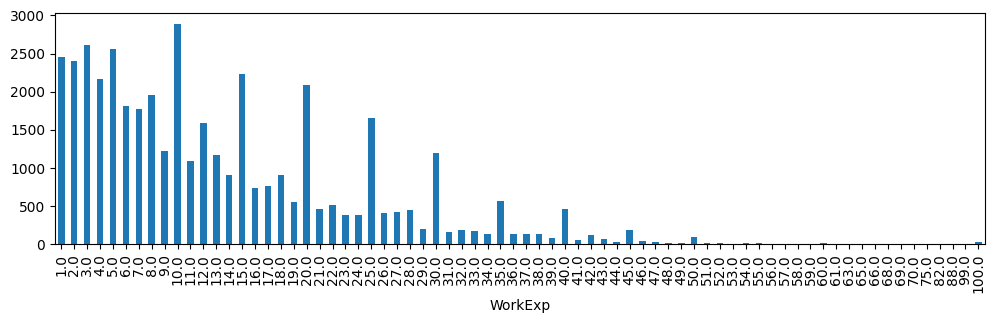

In [14]:
vc = this.value_counts().sort_index()
vc.plot(kind='bar',figsize=(12,3))

In [15]:
#LearnCodeChoose, MC, Nominal
this = df['LearnCodeChoose']
print("This column is","'LearnCodeChoose', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
percentage(vc)

This column is 'LearnCodeChoose', MC, Nominal
dtype: object
isnull().sum(): 2333
Yes, I am not new to coding but am learning new coding techniques or programming language        32,362(69.06%)
No, I am not new to coding and did not learn new coding techniques or programming languages      12,501(26.68%)
Yes, I am new to coding or currently a student                                                    1,995( 4.26%)


In [ ]:
#LearnCode, MC, Multi-label
this = df['LearnCode']
print("This column is","'LearnCode', MC, Multi-label")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.str.split(';').explode().value_counts()
percentage(vc)

This column is 'LearnCode', MC, Multi-label
dtype: object
isnull().sum(): 15635
Technical documentation (is generated for/by the tool or system)            22,739(15.67%)
Other online resources (e.g. standard search, forum, online community)      19,701(13.58%)
Stack Overflow or Stack Exchange                                            17,245(11.89%)
Videos (not associated with specific online course or certification)        16,771(11.56%)
AI CodeGen tools or AI-enabled apps                                         14,753(10.17%)
Blogs or podcasts                                                           11,688( 8.06%)
Online Courses or Certification (includes all media types)                  10,973( 7.56%)
Books / Physical media                                                      10,187( 7.02%)
Colleague or on-the-job training                                             8,596( 5.93%)
School (i.e., University, College, etc)                                      5,561( 3.83%)
Games or c

In [16]:
#LearnCodeAI, MC, Nominal
this = df['LearnCodeAI']
print("This column is","'LearnCodeAI', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
percentage(vc)

This column is 'LearnCodeAI', MC, Nominal
dtype: object
isnull().sum(): 3990
Yes, I learned how to use AI-enabled tools required for my job or to benefit my career                                  16,403(36.29%)
Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies                                     14,027(31.03%)
No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies             5,282(11.69%)
No, I didn't spend time learning in the past year                                                                        4,864(10.76%)
No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career       4,625(10.23%)


In [ ]:
#AILearnHow, MC, Multi-label
this = df['AILearnHow']
print("This column is","'AILearnHow', MC, Multi-label")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.str.split(';').explode().value_counts()
percentage(vc)

This column is 'AILearnHow', MC, Multi-label
dtype: object
isnull().sum(): 20934
AI CodeGen tools or AI-enabled apps                                         14,824(18.31%)
Other online resources (e.g. standard search, forum, online community)      12,480(15.41%)
Technical documentation (is generated for/by the tool or system)            12,001(14.82%)
Videos (not associated with specific online course or certification)        10,945(13.52%)
Blogs or podcasts                                                            8,100(10.00%)
Colleague or on-the-job training                                             6,082( 7.51%)
Stack Overflow or Stack Exchange                                             4,787( 5.91%)
Online Courses or Certification (includes all media types)                   4,637( 5.73%)
Books / Physical media                                                       2,410( 2.98%)
School (i.e., University, College, etc)                                      1,751( 2.16%)
Other (pl

This column is 'YearsCode', TE, Numeric
dtype: float64
isnull().sum(): 6149


<Axes: xlabel='YearsCode'>

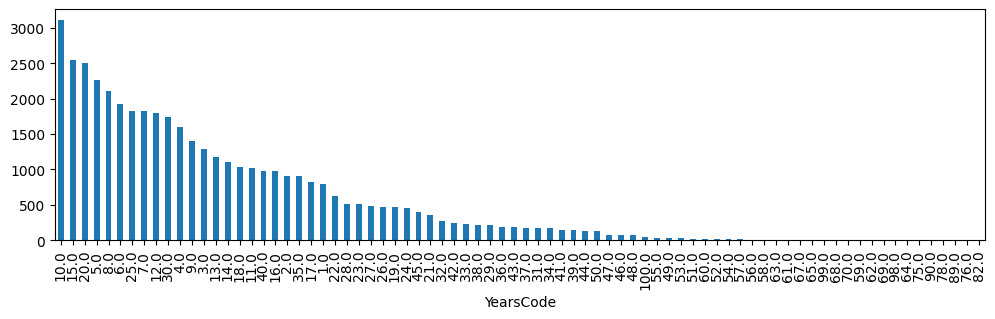

In [17]:
#YearsCode, TE, Numeric
this = df['YearsCode']
print("This column is","'YearsCode', TE, Numeric")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
vc.plot(kind='bar',figsize=(12,3))

<Axes: xlabel='YearsCode'>

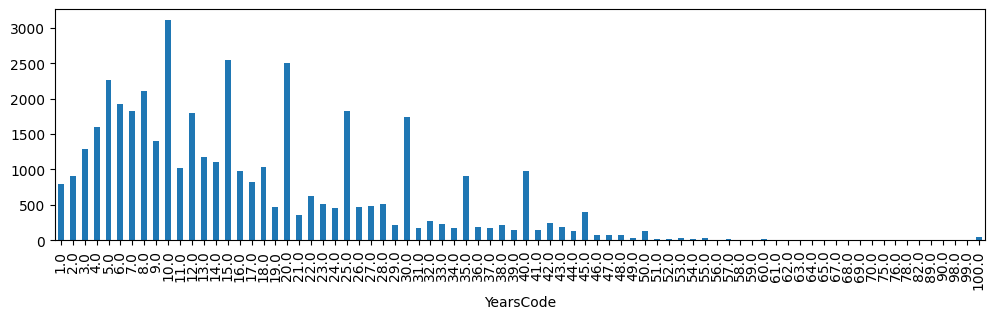

In [18]:
vc = this.value_counts().sort_index()
vc.plot(kind='bar',figsize=(12,3))

This column is 'DevType', MC, Nominal
dtype: object
isnull().sum(): 5511
Developer, full-stack                              12,351(28.28%)
Developer, back-end                                 6,453(14.77%)
Student                                             3,008( 6.89%)
Architect, software or solutions                    2,684( 6.14%)
Developer, front-end                                1,974( 4.52%)
Developer, desktop or enterprise applications       1,919( 4.39%)
Other (please specify):                             1,825( 4.18%)
Developer, mobile                                   1,391( 3.18%)
Developer, embedded applications or devices         1,274( 2.92%)
Academic researcher                                 1,131( 2.59%)
Engineering manager                                 1,068( 2.45%)
DevOps engineer or professional                     1,053( 2.41%)
Data engineer                                         770( 1.76%)
AI/ML engineer                                        677( 1.55%)
Dat

<Axes: xlabel='DevType'>

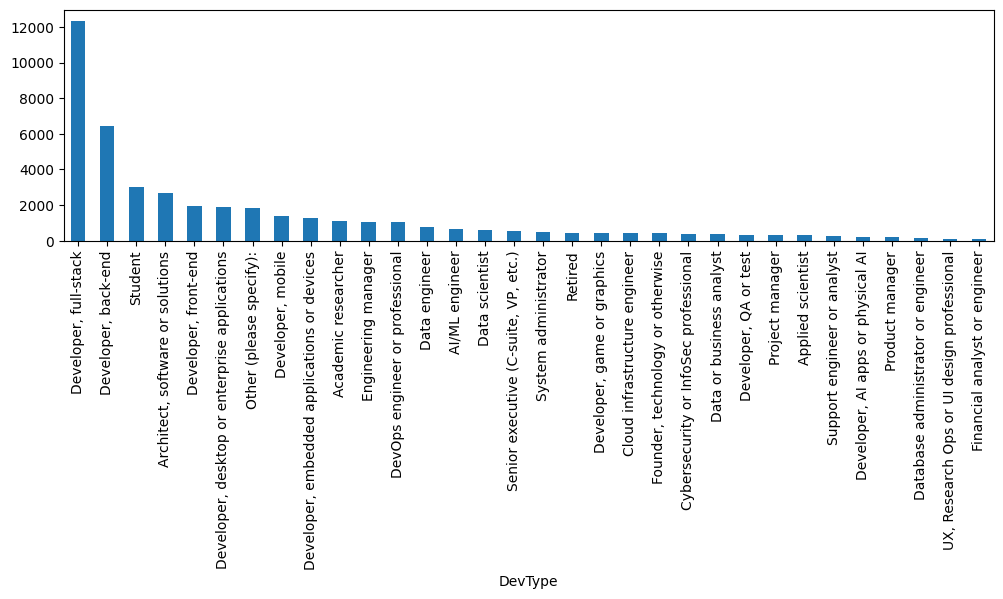

In [19]:
#DevType, MC, Nominal
this = df['DevType']
print("This column is","'DevType', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts()
pd.set_option('display.max_rows', None)
percentage(vc)
vc.plot(kind='bar',figsize=(12,3))

In [20]:
#OrgSize, MC, Nominal
this = df['OrgSize']
print("This column is","'OrgSize', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
percentage(this.value_counts())

This column is 'OrgSize', MC, Nominal
dtype: object
isnull().sum(): 15013
20 to 99 employees                                       6,688(19.57%)
100 to 499 employees                                     6,109(17.87%)
Less than 20 employees                                   5,600(16.38%)
10,000 or more employees                                 4,965(14.53%)
1,000 to 4,999 employees                                 4,156(12.16%)
500 to 999 employees                                     2,361( 6.91%)
Just me - I am a freelancer, sole proprietor, etc.       1,763( 5.16%)
5,000 to 9,999 employees                                 1,604( 4.69%)
I don’t know                                               932( 2.73%)


In [21]:
#ICorPM, MC, Nominal
this = df['ICorPM']
print("This column is","'ICorPM', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
percentage(this.value_counts())

This column is 'ICorPM', MC, Nominal
dtype: object
isnull().sum(): 15948
Individual contributor      28,341(85.25%)
People manager               4,902(14.75%)


In [22]:
#RemoteWork, MC, Nominal
this = df['RemoteWork']
print("This column is","'RemoteWork', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
percentage(this.value_counts())

This column is 'RemoteWork', MC, Nominal
dtype: object
isnull().sum(): 15411
Remote                                                                            10,931(32.36%)
Hybrid (some remote, leans heavy to in-person)                                     6,732(19.93%)
In-person                                                                          6,042(17.89%)
Hybrid (some in-person, leans heavy to flexibility)                                5,831(17.26%)
Your choice (very flexible, you can come in when you want or just as needed)       4,244(12.56%)


In [23]:
#PurchaseInfluence, MC, Nominal
this = df['PurchaseInfluence']
print("This column is","'PurchaseInfluence', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
percentage(this.value_counts())

This column is 'PurchaseInfluence', MC, Nominal
dtype: object
isnull().sum(): 11754
No                                                                                                                                      19,697(52.61%)
Yes, I influenced the purchase of a substantial addition to the tech stack                                                               7,430(19.85%)
Yes, I endorsed a tool that was open-source and is currently used by more than just myself but no purchase was made                      5,794(15.48%)
Yes, I influenced the purchase of a tool that more than five colleagues use but it is not a substantial addition to the tech stack       3,113( 8.32%)
Yes, I endorsed a tool that was ultimately not purchased or used at my organization                                                      1,403( 3.75%)


In [24]:
#TechEndorseIntro, MC, Nominal
this = df['TechEndorseIntro']
print("This column is","'TechEndorseIntro', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
sites = this.value_counts()
sites

This column is 'TechEndorseIntro', MC, Nominal
dtype: object
isnull().sum(): 11635


TechEndorseIntro
Work                25947
Personal Project     9793
School               1816
Name: count, dtype: int64

In [25]:
#TechEndorse_, RO, Ordinal
te_cols = [c for c in df.columns if c.startswith("TechEndorse_")
        and not c.endswith("TEXT")]
print(*te_cols,sep=',')

TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13


In [26]:
te_ql = [
    "AI integration or AI Agent capabilities", #1
    "Easy-to-use API", #2
    "Robust and complete API", #3
    "Customizable and manageable codebase", #4
    "Reputation for quality", #5
    "Connected to an open source project", #6
    "Good brand and public image", #7
    "Reliability and low latency", #8
    "Costs are manageable", #9
    "Other" #10
]


In [27]:
these = df[te_cols]
te_qs = pd.Series(te_ql,index=te_cols)
print("isnull().sum():",these.isnull().sum())
te_mean = these.mean()
te_median = these.median().astype('int')
te_mode = these.mode().astype('int')
te_df = pd.concat([te_qs.rename("Question"),te_mean.rename("Mean"),te_median.rename("Median Rank"),
                   te_mode.iloc[0].rename("Mode Rank")],axis=1)
te_df.sort_values(by='Mean',inplace=True)
te_overall_rank = pd.Series(range(1,11),index=te_df.index)
te_df["Overall Rank"] = te_overall_rank
te_df[['Question','Overall Rank','Median Rank','Mode Rank']].style.hide(axis='index')

isnull().sum(): TechEndorse_1     13216
TechEndorse_2     13216
TechEndorse_3     13216
TechEndorse_4     13216
TechEndorse_5     13216
TechEndorse_6     13216
TechEndorse_7     13216
TechEndorse_8     13216
TechEndorse_9     13216
TechEndorse_13    13216
dtype: int64


Question,Overall Rank,Median Rank,Mode Rank
Easy-to-use API,1,4,2
Robust and complete API,2,4,2
Reputation for quality,3,4,1
Reliability and low latency,4,4,3
Costs are manageable,5,4,1
Connected to an open source project,6,5,1
Customizable and manageable codebase,7,6,7
Good brand and public image,8,7,8
AI integration or AI Agent capabilities,9,9,9
Other,10,10,10


In [28]:
#TechOppose_, RO, Ordinal
to_cols = [c for c in df.columns if c.startswith("TechOppose_")
        and not c.endswith("TEXT")]
print(*to_cols,sep=',')

TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15


In [29]:
to_ql = [
    "Lack of AI or AI agents", #1
    "Poor usability", #2
    "Lack of or sub-par API", #3
    "Inefficient or time-costly", #5
    "Prohibitive pricing", #7
    "Security or privacy concerns", #9
    "Available of better alternatives", #11
    "Outdated or obsolete technology or features",
    "Ethical concerns",
    "Other" #10
]


In [30]:
these = df[to_cols]
to_qs = pd.Series(to_ql,index=to_cols)
print("isnull().sum():",these.isnull().sum())
to_mean = these.mean()
to_median = these.median().astype('int')
to_mode = these.mode().astype('int')
to_df = pd.concat([to_qs.rename("Question"),to_mean.rename("Mean"),to_median.rename("Median Rank"),
                   to_mode.iloc[0].rename("Mode Rank")],axis=1)
to_df.sort_values(by='Mean',inplace=True)
to_overall_rank = pd.Series(range(1,11),index=to_df.index)
to_df["Overall Rank"] = to_overall_rank
to_df[['Question','Overall Rank','Median Rank','Mode Rank']].style.hide(axis='index')

isnull().sum(): TechOppose_1     14932
TechOppose_2     14932
TechOppose_3     14932
TechOppose_5     14932
TechOppose_7     14932
TechOppose_9     14932
TechOppose_11    14932
TechOppose_13    14932
TechOppose_16    14932
TechOppose_15    14932
dtype: int64


Question,Overall Rank,Median Rank,Mode Rank
Security or privacy concerns,1,3,1
Prohibitive pricing,2,4,1
Available of better alternatives,3,4,1
Poor usability,4,4,4
Inefficient or time-costly,5,5,5
Outdated or obsolete technology or features,6,5,8
Ethical concerns,7,6,8
Lack of or sub-par API,8,6,8
Lack of AI or AI agents,9,9,9
Other,10,10,10


In [31]:
#Industry, MC, Nominal
this = df['Industry']
print("This column is","'Industry', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = df['Industry'].value_counts()
percentage(vc)

This column is 'Industry', MC, Nominal
dtype: object
isnull().sum(): 15549
Software Development                            16,282(48.40%)
Other:                                           2,667( 7.93%)
Internet, Telecomm or Information Services       1,698( 5.05%)
Fintech                                          1,690( 5.02%)
Banking/Financial Services                       1,437( 4.27%)
Healthcare                                       1,397( 4.15%)
Manufacturing                                    1,315( 3.91%)
Government                                       1,183( 3.52%)
Higher Education                                 1,167( 3.47%)
Retail and Consumer Services                     1,053( 3.13%)
Transportation, or Supply Chain                    910( 2.70%)
Computer Systems Design and Services               894( 2.66%)
Media & Advertising Services                       773( 2.30%)
Energy                                             742( 2.21%)
Insurance                                  

In [32]:
#JobSatPoints, RO, Ordinal
js_cols = [c for c in df.columns if c.startswith('JobSatPoints_') and not c.endswith('_TEXT')]
print(*js_cols,sep=',')

JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16


In [33]:
js_ql = ["Control over the level of quality in projects",
"Autonomy and trust to manage your own tasks",
"Collaboration and support from a team",
"Expert mentors",
"Opportunities to mentor and lead junior-level coworkers",
"Developing specialized expertise",
"Solving real-world problems",
"Job stability and career growth with a single employer",
"Innovation through solving challenging and complex problems",
"Working with new technologies and tools",
"Competitive pay and benefits",
"Recognition from peers for your work",
"Recognition from leadership for your work",
"Other",
"You like your manager"]

In [34]:
these = df[js_cols]
js_qs = pd.Series(js_ql,index=js_cols)
print("isnull().sum():",these.isnull().sum())
js_mean = these.mean()
js_median = these.median().astype('int')
js_mode = these.mode().astype('int')
js_df = pd.concat([js_qs.rename("Question"),js_mean.rename("Mean"),js_median.rename("Median Rank"),
                   js_mode.iloc[0].rename("Mode Rank")],axis=1)
js_df.sort_values(by='Mean',inplace=True)
js_overall_rank = pd.Series(range(1,16),index=js_df.index)
js_df["Overall Rank"] = range(1,16) #js_overall_rank.values
js_df[['Question','Overall Rank','Median Rank','Mode Rank']].style.hide(axis='index')

isnull().sum(): JobSatPoints_1     24248
JobSatPoints_2     24248
JobSatPoints_3     24248
JobSatPoints_4     24248
JobSatPoints_5     24248
JobSatPoints_6     24248
JobSatPoints_7     24248
JobSatPoints_8     24248
JobSatPoints_9     24248
JobSatPoints_10    24248
JobSatPoints_11    24248
JobSatPoints_13    24248
JobSatPoints_14    24248
JobSatPoints_15    24248
JobSatPoints_16    24248
dtype: int64


Question,Overall Rank,Median Rank,Mode Rank
Autonomy and trust to manage your own tasks,1,4,1
Competitive pay and benefits,2,5,1
Solving real-world problems,3,5,1
Innovation through solving challenging and complex problems,4,6,2
Control over the level of quality in projects,5,6,4
Job stability and career growth with a single employer,6,7,1
Collaboration and support from a team,7,7,8
Working with new technologies and tools,8,7,5
You like your manager,9,8,14
Developing specialized expertise,10,8,11


In [35]:
#AIThreat, NewRole, MC, Nominal
vc = df['AIThreat'].value_counts()
print("Do you believe AI is a threat to your current job?")
percentage(vc)
vc = df['NewRole'].value_counts()
print("\nHave you considered a career change or transitioned into a new role in the past year?")
percentage(vc)

Do you believe AI is a threat to your current job?
No                22,958(63.63%)
I'm not sure       7,700(21.34%)
Yes                5,420(15.02%)

Have you considered a career change or transitioned into a new role in the past year?
I have neither consider or transitioned into a new career or industry            16,205(45.61%)
I have somewhat considered changing my career and/or the industry I work in      10,233(28.80%)
I have strongly considered changing my career and/or the industry I work in       5,253(14.79%)
I have transitioned into a new career and/or industry voluntarily                 3,111( 8.76%)
I have transitioned into a new career and/or industry involuntarily                 725( 2.04%)


This column is 'ToolCountWork', MC, Nominal
dtype: float64
isnull().sum(): 21580


<Axes: xlabel='ToolCountWork'>

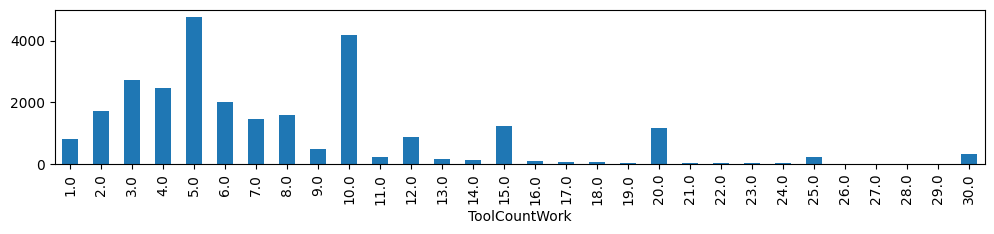

In [36]:
#ToolCountWork, MC, Nominal
this = df['ToolCountWork']
print("This column is","'ToolCountWork', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts().sort_index()
vc = vc[(vc.index<=30)&(vc.index!=0)]
vc.plot(kind='bar',figsize=(12,2))

<Axes: xlabel='ToolCountWork'>

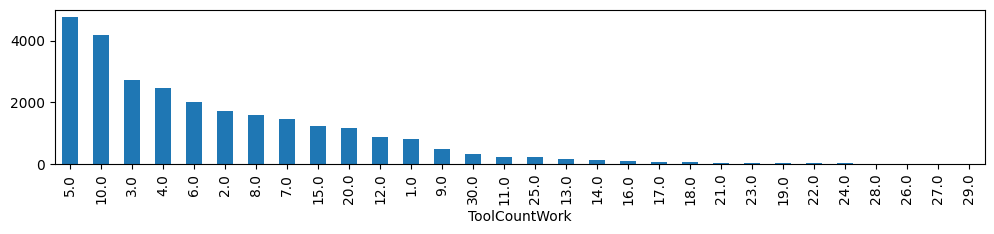

In [37]:
vc = vc.sort_values(ascending=False)
vc.plot(kind='bar',figsize=(12,2))


This column is 'ToolCountPersonal', MC, Nominal
dtype: float64
isnull().sum(): 23609


<Axes: xlabel='ToolCountPersonal'>

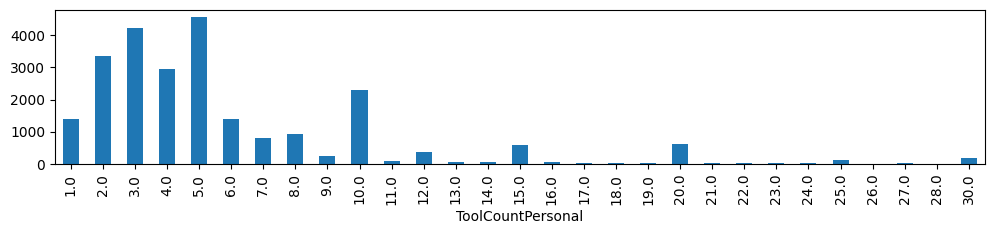

In [38]:
#ToolCountPersonal, MC, Nominal
this = df['ToolCountPersonal']
print("This column is","'ToolCountPersonal', MC, Nominal")
print("dtype:",this.dtype)
print("isnull().sum():",this.isnull().sum())
vc = this.value_counts().sort_index()
vc = vc[(vc.index<=30)&(vc.index!=0)]
vc.plot(kind='bar',figsize=(12,2))

<Axes: xlabel='ToolCountPersonal'>

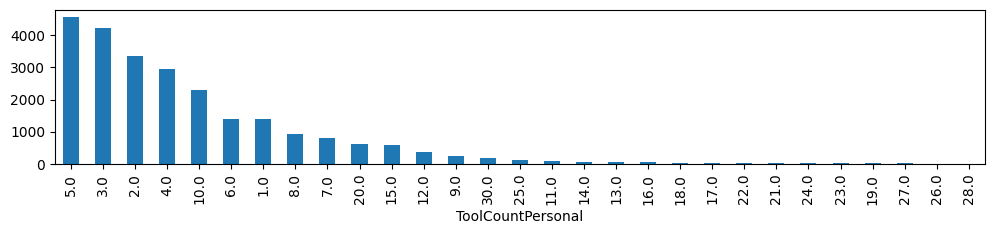

In [39]:
vc = vc.sort_values(ascending=False)
vc.plot(kind='bar',figsize=(12,2))

44 88 132


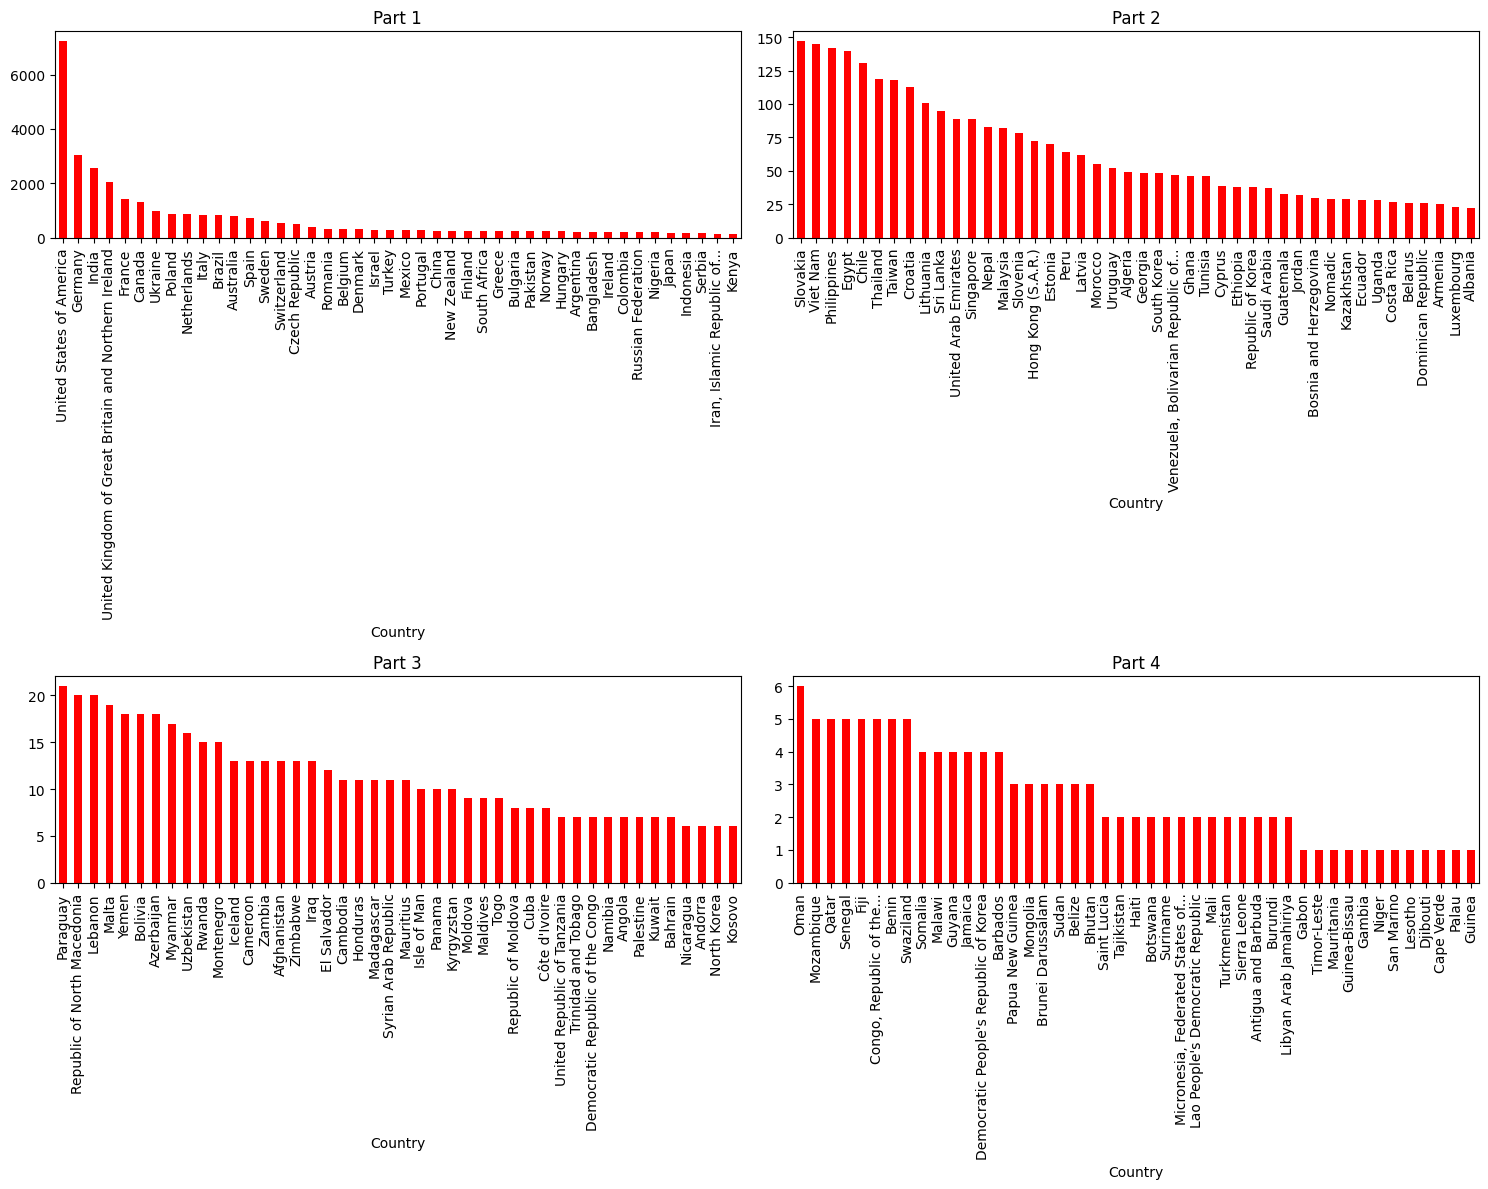

In [43]:
#Country
vc = df['Country'].value_counts()
countries = vc.count()
n4_1 = (countries / 4).astype(int)
n4_2 = (countries / 2).astype(int)
n4_3 = (countries / 4 * 3).astype(int)
print(n4_1,n4_2,n4_3)
plt.figure(figsize=(15, 12))

# 2행 2열 중 첫 번째 영역
plt.subplot(2, 2, 1)
vc[0:n4_1].plot(kind='bar',color='red')
plt.title('Part 1')

# 2행 2열 중 두 번째 영역
plt.subplot(2, 2, 2)
vc[n4_1:n4_2].plot(kind='bar', color='red')
plt.title('Part 2')

# 2행 2열 중 세 번째 영역
plt.subplot(2, 2, 3)
vc[n4_2:n4_3].plot(kind='bar',color='red')
plt.title('Part 3')

# 2행 2열 중 네 번째 영역
plt.subplot(2, 2, 4)
vc[n4_3:countries].plot(kind='bar', color='red')
plt.title('Part 4')

plt.tight_layout()
plt.show()

In [40]:
#Currency, MC, Nominal
vc = df['Currency'].value_counts()
code = []
name = []
for i in range(len(vc.index)):
    wl = vc.index[i].split()
    code.append(wl[0])
    name.append(" ".join(wl[1:]))
print(len(code),len(name))
name

142 142


['European Euro',
 'United States dollar',
 'Indian rupee',
 'Pound sterling',
 'Canadian dollar',
 'Polish zloty',
 'Australian dollar',
 'Brazilian real',
 'Ukrainian hryvnia',
 'Swedish krona',
 'Swiss franc',
 'Czech koruna',
 'Danish krone',
 'Israeli new shekel',
 'Mexican peso',
 'New Zealand dollar',
 'Turkish lira',
 'Romanian leu',
 'South African rand',
 'Chinese Yuan Renminbi',
 'Norwegian krone',
 'Bulgarian lev',
 'Hungarian forint',
 'Pakistani rupee',
 'Bangladeshi taka',
 'Japanese yen',
 'Russian ruble',
 'Indonesian rupiah',
 'Colombian peso',
 'Nigerian naira',
 'Argentine peso',
 'Vietnamese dong',
 'Kenyan shilling',
 'Philippine peso',
 'Iranian rial',
 'Chilean peso',
 'Egyptian pound',
 'New Taiwan dollar',
 'Thai baht',
 'Serbian dinar',
 'Singapore dollar',
 'South Korean won',
 'Sri Lankan rupee',
 'Malaysian ringgit',
 'United Arab Emirates dirham',
 'Hong Kong dollar',
 'Nepalese rupee',
 'Peruvian sol',
 'Moroccan dirham',
 'Ghanaian cedi',
 'Tunisian din

In [41]:
#Country and Currency
cc = df[['Country','Currency']]
cc.loc[cc['Country']=='United States of America','Currency'].value_counts()
cc.loc[(cc['Country']=='South Korea')|(cc['Country']=='Republic of Korea'),'Currency'].value_counts()
#cc.groupby(['Country'])['Currency']

Currency
KRW\tSouth Korean won       81
USD United States dollar     5
Name: count, dtype: int64

In [42]:
#CompTotal and ConvertedCompYearly
pd.set_option('display.max_rows', None)
comp_data = df[['Currency','CompTotal','ConvertedCompYearly']]
comp_data["ExchangeRate"] = df['ConvertedCompYearly'] / df['CompTotal']
ex_min = comp_data.groupby('Currency')['ExchangeRate'].min()
ex_max = comp_data.groupby('Currency')['ExchangeRate'].max()
ex_diff = ex_max - ex_min
ex_diff.sort_values(ascending=False,inplace=True)
ex_diff

C:\Users\IMST\AppData\Local\Temp\ipykernel_27912\1549580194.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_data["ExchangeRate"] = df['ConvertedCompYearly'] / df['CompTotal']


Currency
BGN\tBulgarian lev                              4.076923e-01
GBP Pound sterling                              3.750000e-01
KWD\tKuwaiti dinar                              2.700000e-01
EUR European Euro                               2.000000e-01
CAD Canadian dollar                             7.407407e-02
CNY\tChinese Yuan Renminbi                      6.666667e-02
TND\tTunisian dinar                             2.371053e-02
PLN Polish zloty                                2.333333e-02
TRY\tTurkish lira                               1.703704e-02
LYD Libyan dinar                                1.571429e-02
CHF\tSwiss franc                                1.401099e-02
INR Indian rupee                                1.222222e-02
DKK\tDanish krone                               1.116667e-02
TWD New Taiwan dollar                           1.089744e-02
AUD\tAustralian dollar                          7.142857e-03
BRL Brazilian real                              5.913978e-03
SEK\tSwedish kr

In [43]:
#LanguageChoice
df['LanguageChoice'].value_counts()

LanguageChoice
Yes    31553
No       661
Name: count, dtype: int64

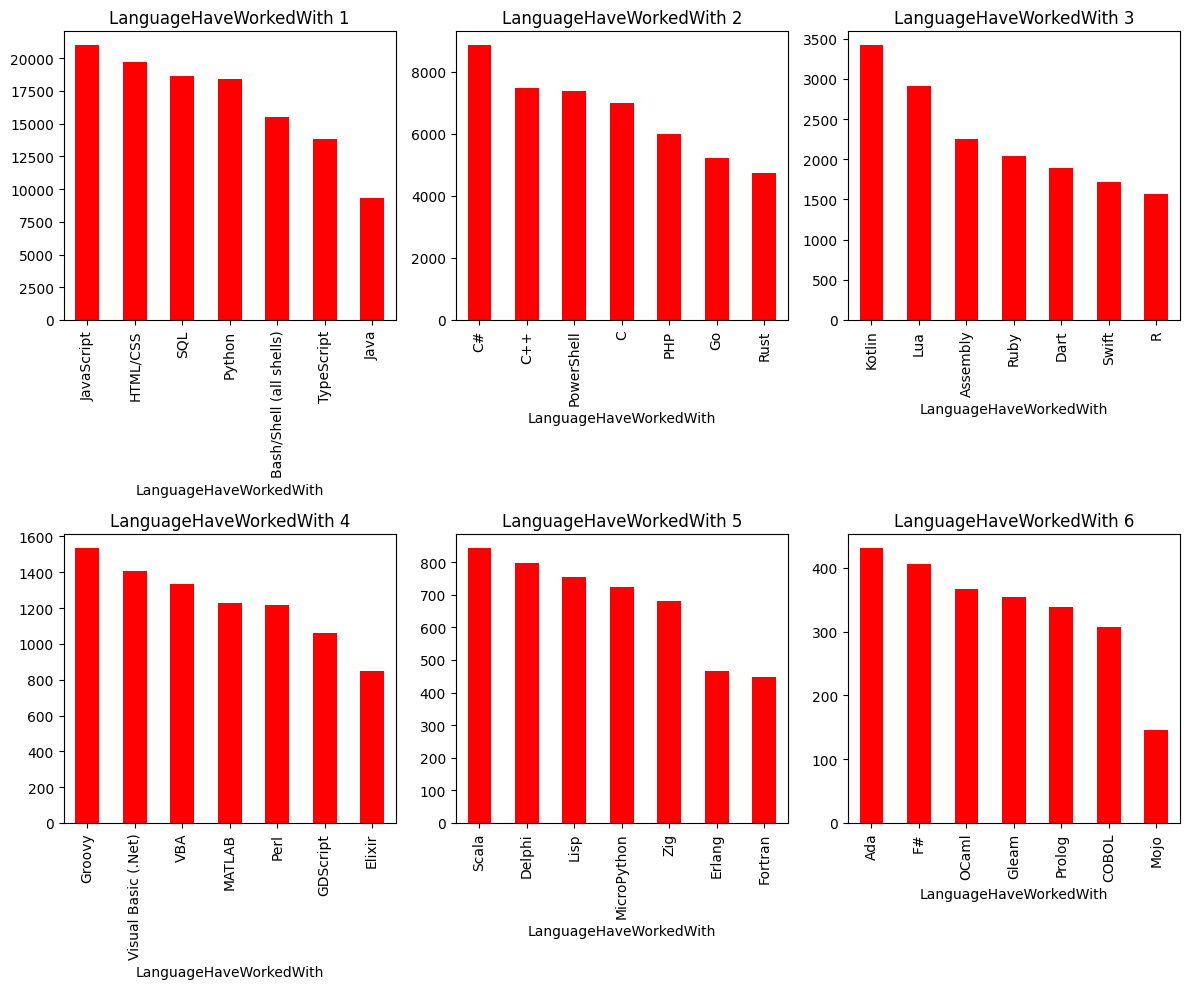

In [44]:
#LanguageHaveWordedWith, LanguageWantToWorkWith, LanguageAdmired
vc_o = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
#print(*vc.index,sep=',')
#print("Number of languages is ",len(vc))
#vc.plot(kind='bar', figsize=(15,4),color='red')
plt.figure(figsize=(12,10))
langs = vc_o.count()
for i in range(0,6):
    plt.subplot(2,3,i+1)
    si = int(langs*i/6)
    ei = int(langs*(i+1)/6)
    vc_o[si:ei].plot(kind='bar',color='red')
    plt.title(f"LanguageHaveWorkedWith {i+1}")
plt.tight_layout()
plt.show()

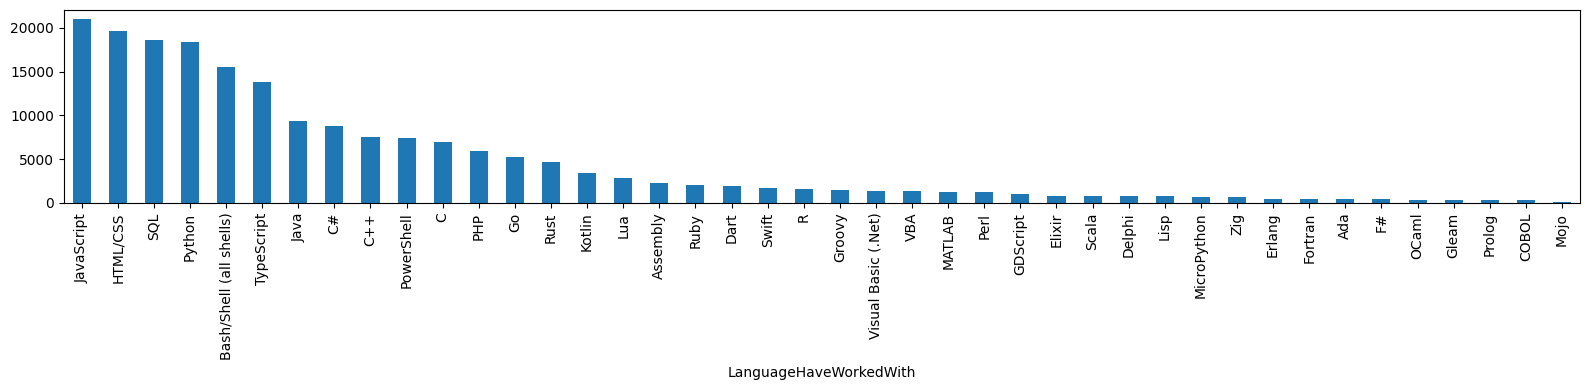

In [45]:
plt.figure(figsize=(16,4))
vc_o.plot(kind='bar')
plt.tight_layout()
plt.show()

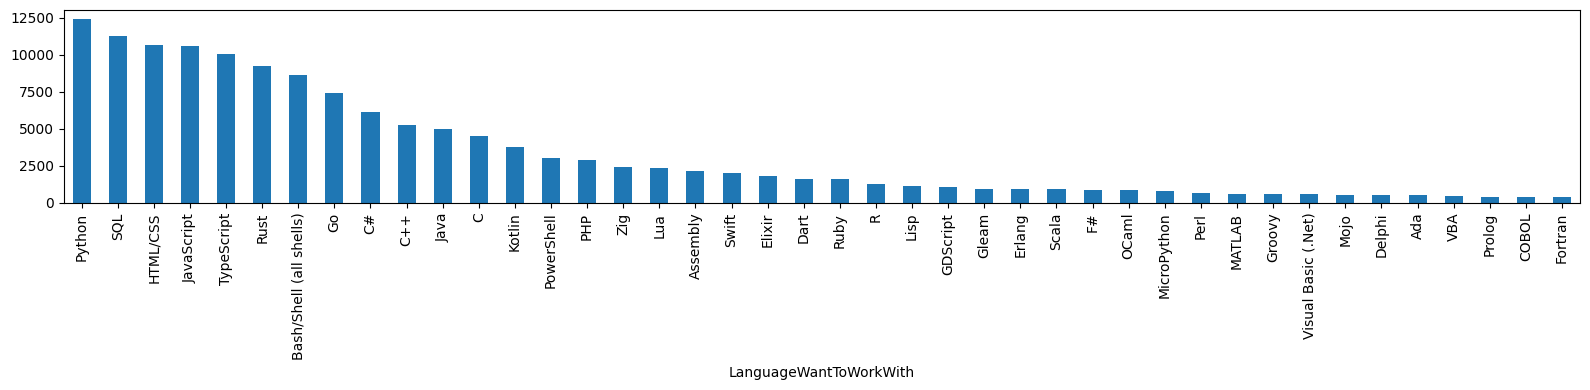

In [46]:
vc_n = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()
plt.figure(figsize=(16,4))
vc_n.plot(kind='bar')
plt.tight_layout()
plt.show()

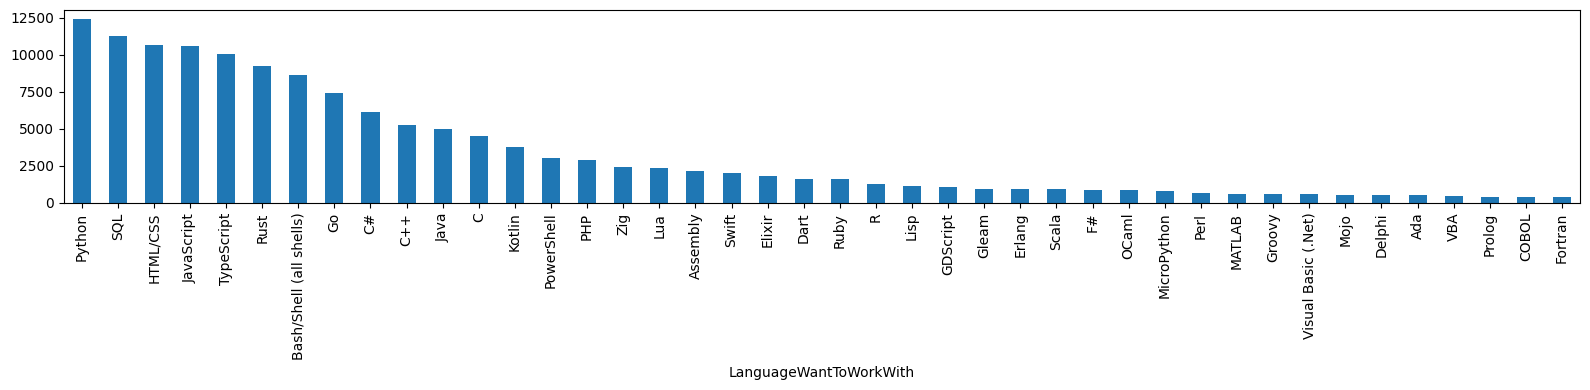

In [47]:
vc_n = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()
plt.figure(figsize=(16,4))
vc_n.plot(kind='bar')
plt.tight_layout()
plt.show()

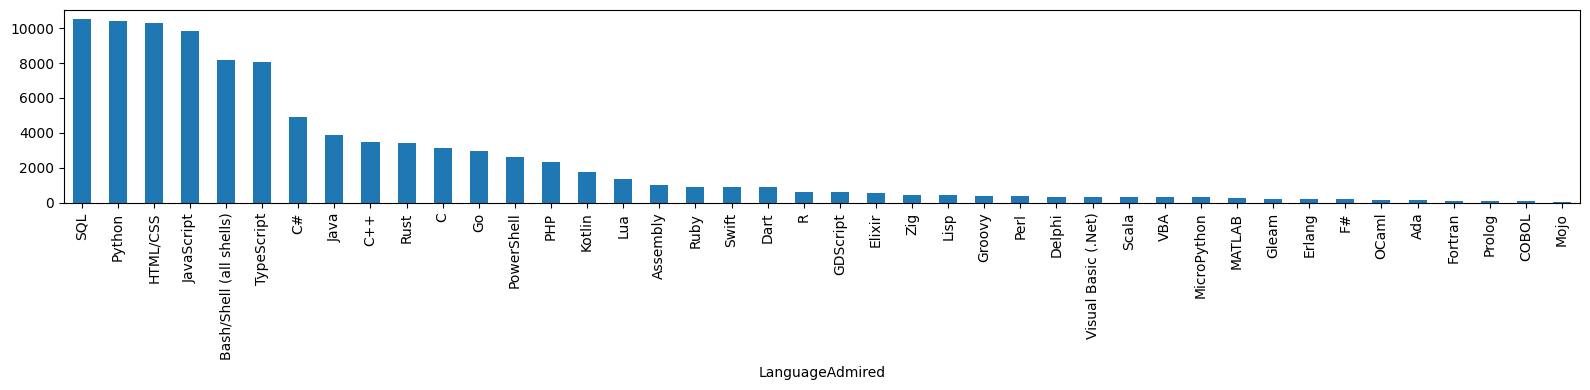

In [48]:
vc_a = df['LanguageAdmired'].str.split(';').explode().value_counts()
plt.figure(figsize=(16,4))
vc_a.plot(kind='bar')
plt.tight_layout()
plt.show()

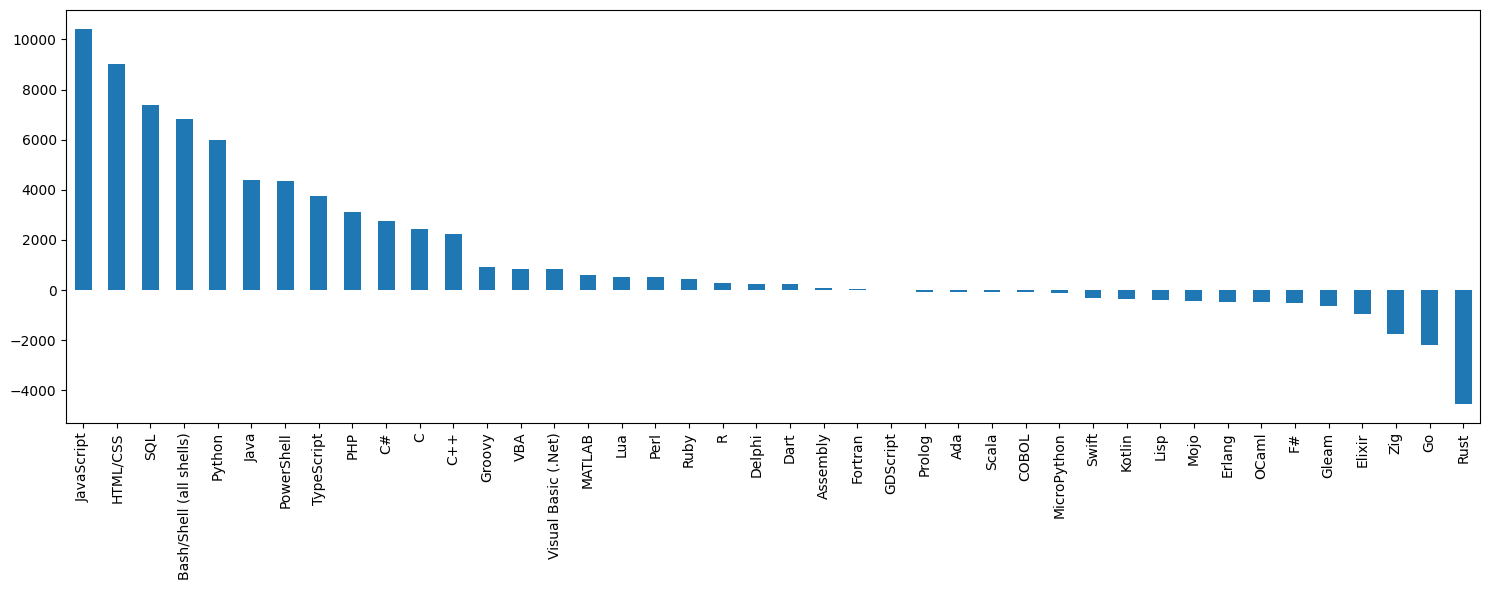

In [49]:
vc_vary = vc_o - vc_n
vc_vary.sort_values(ascending=False,inplace=True)
vc_vary.plot(kind='bar',figsize=(15,6))
plt.tight_layout()
plt.show()

In [50]:
#LanguageHaveEntry, LanguageWantEntry
vc_le = df['LanguagesHaveEntry'].str.split(',').explode().value_counts()
vc_lw = df['LanguagesWantEntry'].str.split(',').explode().value_counts()
df_lang = pd.concat([vc_le.rename("HaveEntry"), vc_lw.rename("WantEntry")], axis=1)
df_lang.sort_values(by='HaveEntry', ascending=False, inplace=True)
df_lang.head(25)
lndx = df_lang.index.sort_values(ascending=False)
lndx
#print(*df_lang.index, sep=',')

Index(['ไทย', 'กลอนใหม่', 'العرببه', 'الانجليزي ه', '{az}-{AZ}- {0-9}', 'zsh',
       'zig', 'zeek script', 'you want to use next year',
       'you used in the past year',
       ...
       ' 10', ' .Net Maui', ' .NET', ' (La)TeX', ' & Javascript.',
       '  SvelteKit', '  Salesforce LWC', '  PosgreSQL PLPgSQL', ' ', ''],
      dtype='object', length=2439)

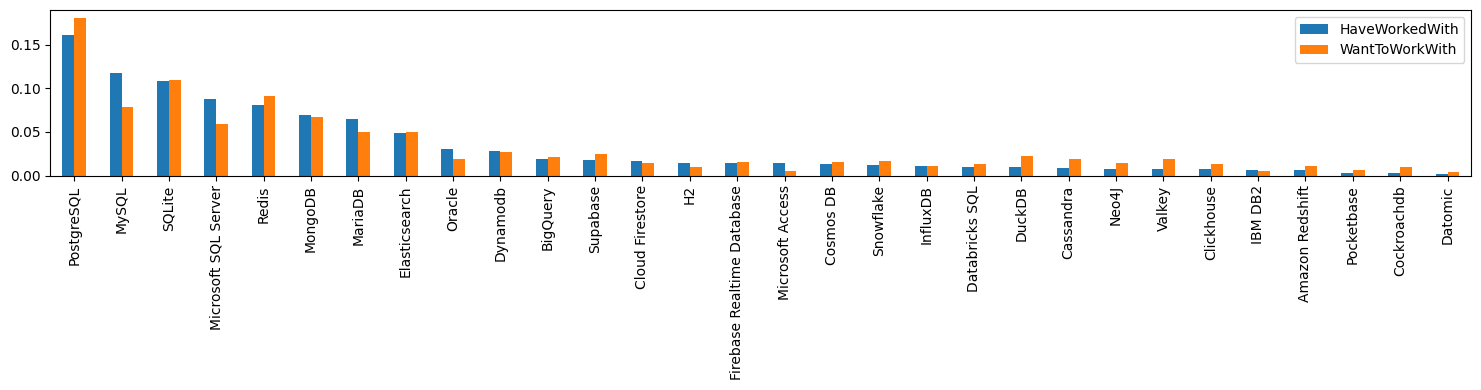

In [51]:
#DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired
vc_o = df['DatabaseHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['DatabaseWantToWorkWith'].str.split(';').explode().value_counts()
vc_a = df['DatabaseAdmired'].str.split(';').explode().value_counts()

vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_database_rate = pd.concat([vc_orate.rename("HaveWorkedWith"),vc_nrate.rename("WantToWorkWith")],axis=1)
df_database_rate.plot(kind='bar',figsize=(15,4))
plt.tight_layout()
plt.show()

In [52]:
#DatabaseHaveEntry, DatabaseWantEntry
vc_de = df['DatabaseHaveEntry'].str.split(',').explode().value_counts()
vc_dw = df['DatabaseWantEntry'].str.split(',').explode().value_counts()
vc_de

DatabaseHaveEntry
Firebird                                                                                                                                                                                                                                                                                                                                                                                    71
CouchDB                                                                                                                                                                                                                                                                                                                                                                                     38
Spanner                                                                                                                                                                                                                 

In [53]:
#PlatformChoice
df['PlatformChoice'].value_counts()

PlatformChoice
Yes    24172
No      7090
Name: count, dtype: int64

<Axes: >

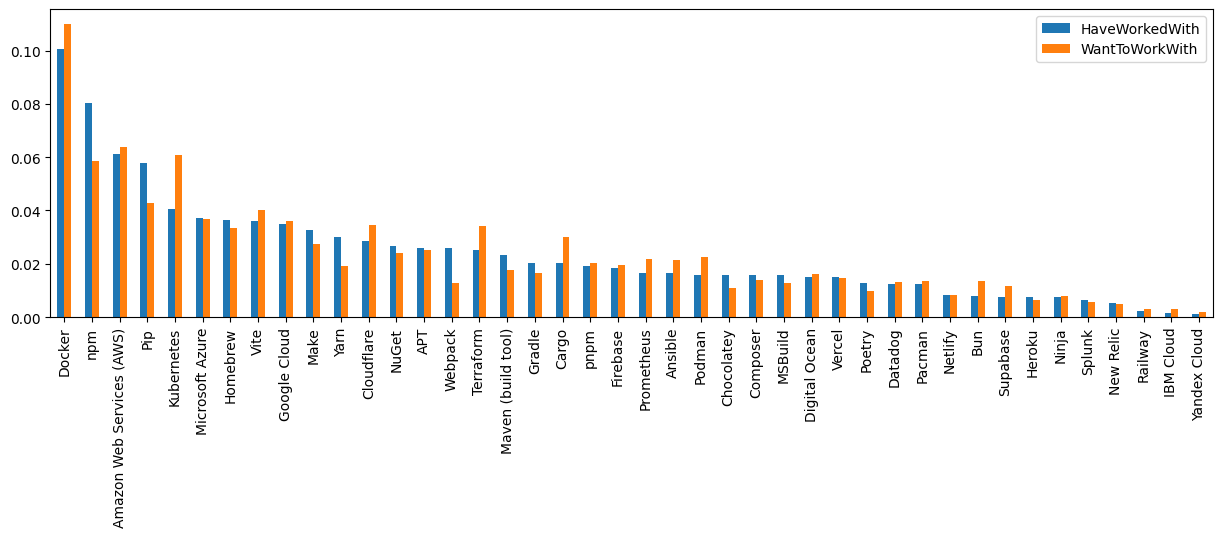

In [54]:
#PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired
vc_o = df['PlatformHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['PlatformWantToWorkWith'].str.split(';').explode().value_counts()
vc_a = df['PlatformAdmired'].str.split(';').explode().value_counts()
df_platform = pd.concat([vc_o.rename("HaveWorkedWith"),vc_n.rename("WantToWorkWith")],axis=1)
vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_platform_rate = pd.concat([vc_orate.rename("HaveWorkedWith"),vc_nrate.rename("WantToWorkWith")],axis=1)
df_platform_rate.plot(kind='bar',figsize=(15,4))

<Axes: >

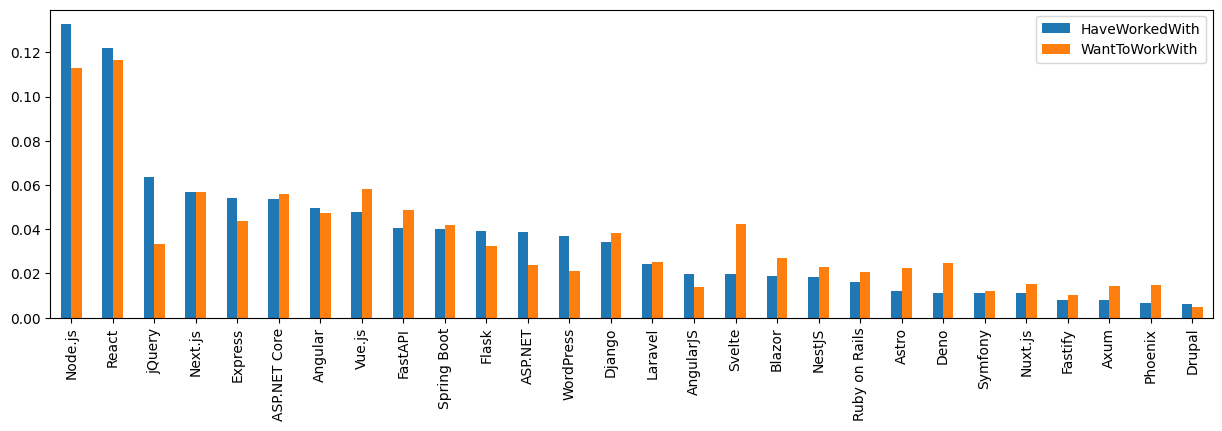

In [55]:
#WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired
vc_o = df['WebframeHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['WebframeWantToWorkWith'].str.split(';').explode().value_counts()
vc_a = df['WebframeAdmired'].str.split(';').explode().value_counts()
df_webframe = pd.concat([vc_o.rename("HaveWorkedWith"),vc_n.rename("WantToWorkWith")],axis=1)
vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_webframe_rate = pd.concat([vc_orate.rename("HaveWorkedWith"),vc_nrate.rename("WantToWorkWith")],axis=1)
df_webframe_rate.plot(kind='bar',figsize=(15,4))

<Axes: >

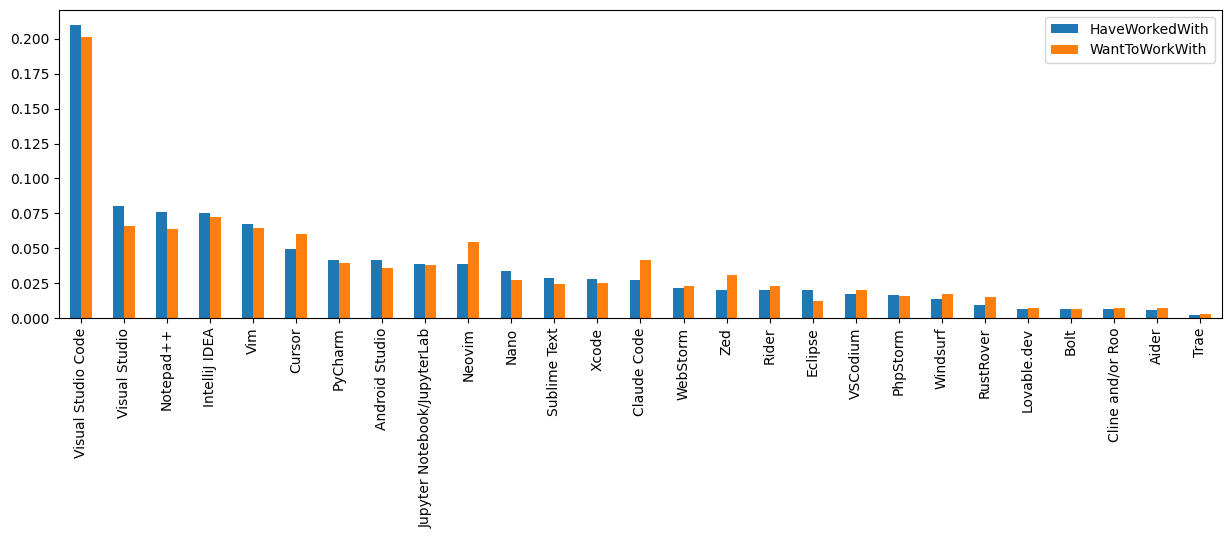

In [56]:
#DevEnvsHaveWorkedWith, DevEnvsWantToWorkWith
vc_o = df['DevEnvsHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['DevEnvsWantToWorkWith'].str.split(';').explode().value_counts()
vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_devenvs_rate = pd.concat([vc_orate.rename("HaveWorkedWith"),vc_nrate.rename("WantToWorkWith")],axis=1)
df_devenvs_rate.plot(kind='bar',figsize=(15,4))

<Axes: >

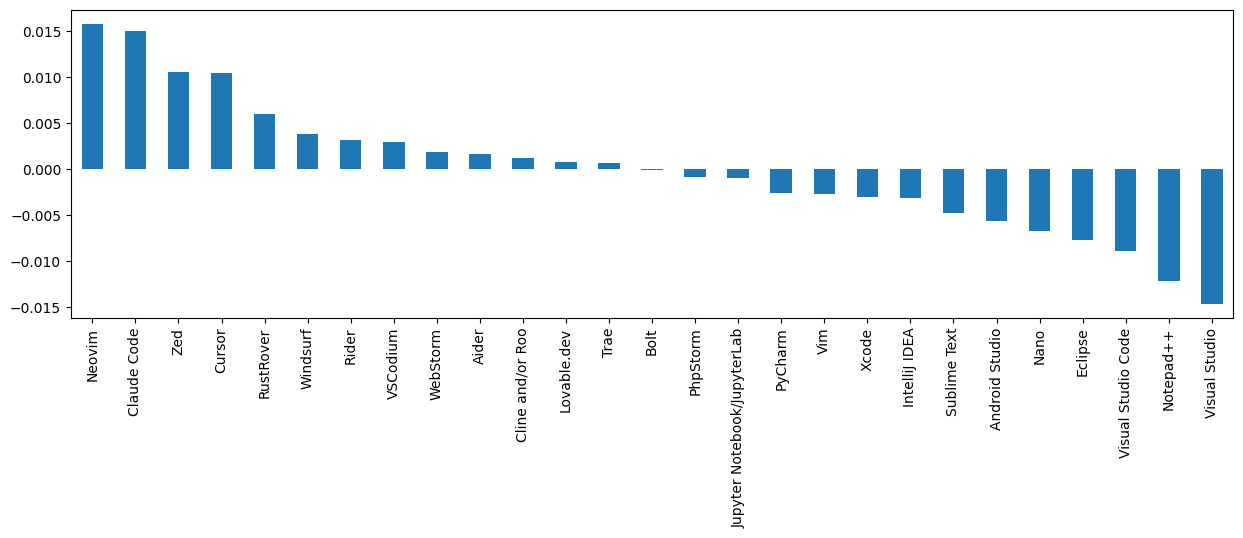

In [57]:
vc_rate_vary = vc_nrate - vc_orate
vc_rate_vary.sort_values(ascending=False,inplace=True)
vc_rate_vary.plot(kind='bar',figsize=(15,4))

<Axes: >

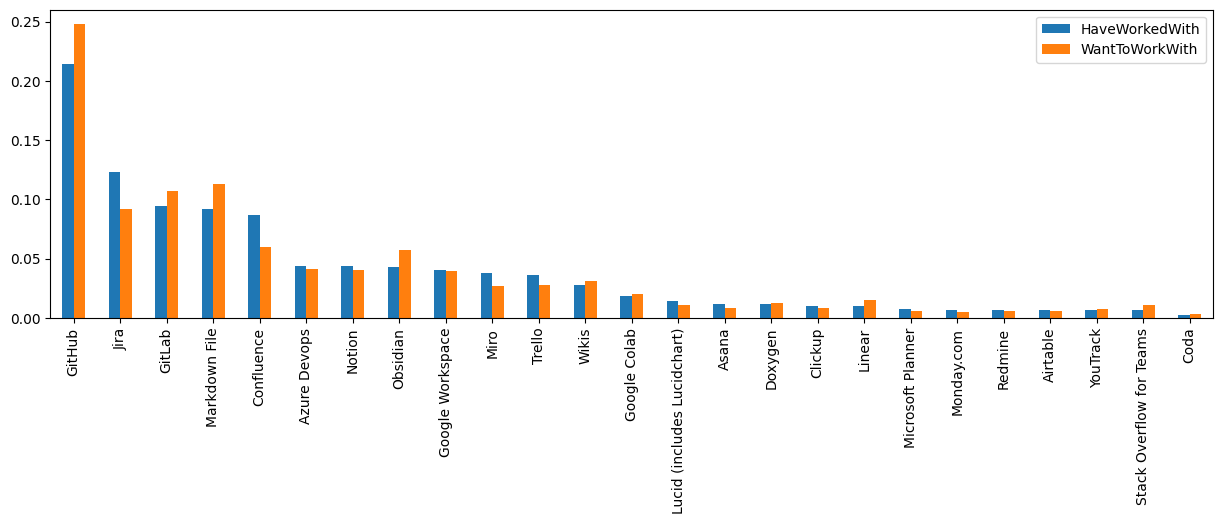

In [58]:
#OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith
vc_o = df['OfficeStackAsyncHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['OfficeStackAsyncWantToWorkWith'].str.split(';').explode().value_counts()
vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_officestack_rate = pd.concat([vc_orate.rename("HaveWorkedWith"),vc_nrate.rename("WantToWorkWith")],axis=1)
df_officestack_rate.plot(kind='bar',figsize=(15,4))

<Axes: >

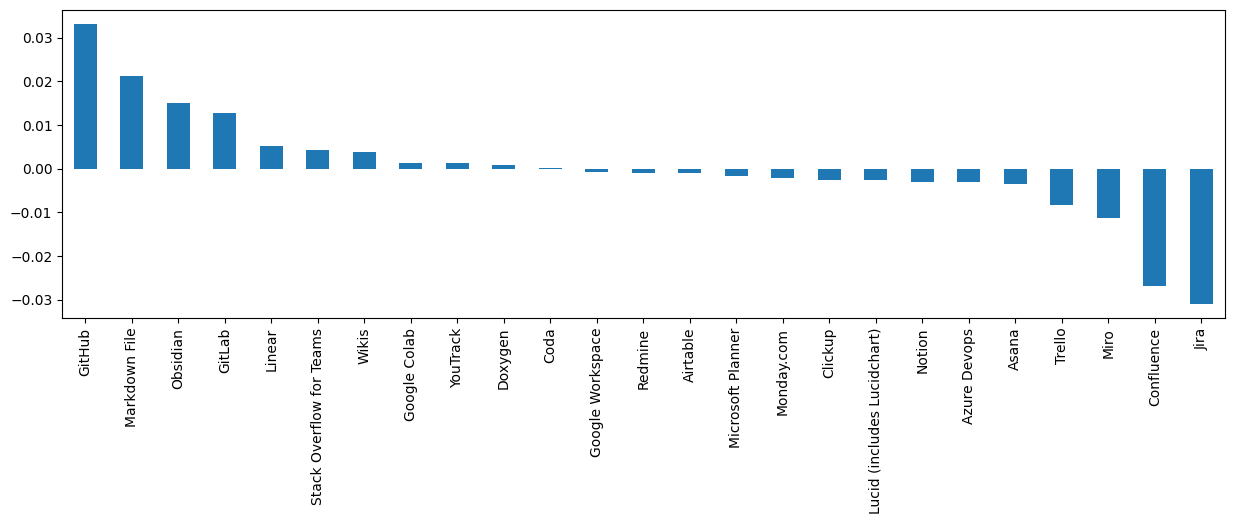

In [59]:
vc_rate_vary = vc_nrate - vc_orate
vc_rate_vary.sort_values(ascending=False,inplace=True)
vc_rate_vary.plot(kind='bar',figsize=(15,4))

<Axes: >

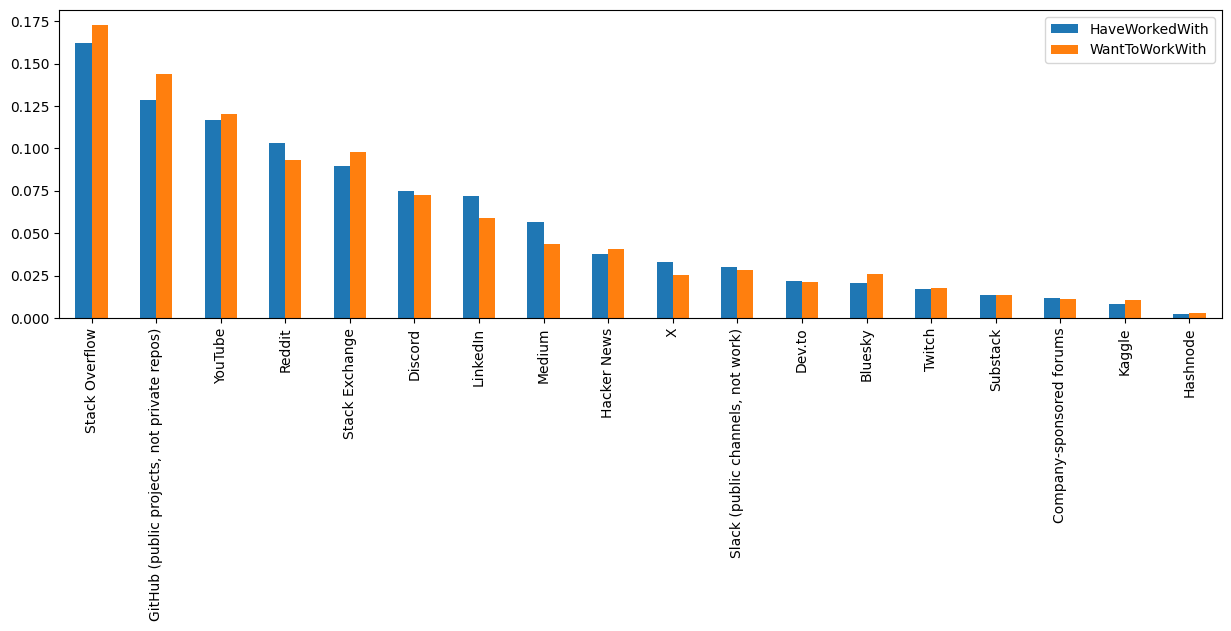

In [60]:
#CommPlatformHaveWorkedWith, CommPlatformWantToWorkWith, CommPlatformAdmired
vc_o = df['CommPlatformHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['CommPlatformWantToWorkWith'].str.split(';').explode().value_counts()
vc_a = df['CommPlatformAdmired'].str.split(';').explode().value_counts()
df_commplatform = pd.concat([vc_o.rename("HaveWorkedWith"),vc_n.rename("WantToWorkWith")],axis=1)
vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_commplatform_rate = pd.concat([vc_orate.rename("HaveWorkedWith"),vc_nrate.rename("WantToWorkWith")],axis=1)
df_commplatform_rate.plot(kind='bar',figsize=(15,4))

<Axes: >

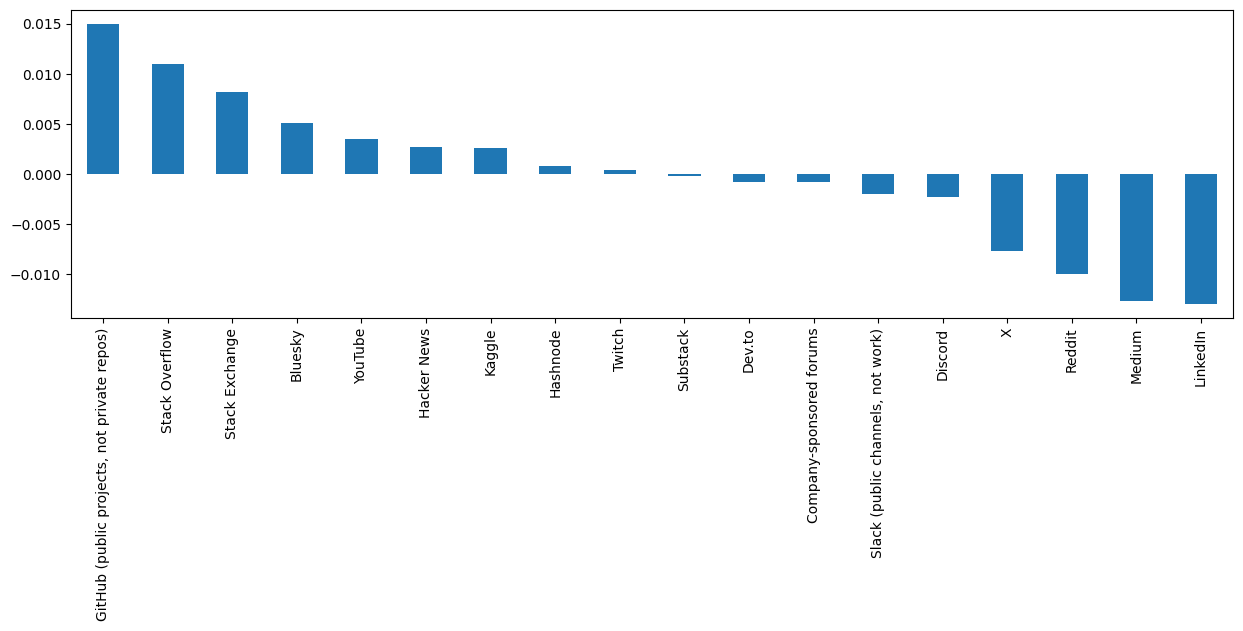

In [61]:
vc_rate_vary = vc_nrate - vc_orate
vc_rate_vary.sort_values(ascending=False,inplace=True)
vc_rate_vary.plot(kind='bar',figsize=(15,4))

<Axes: >

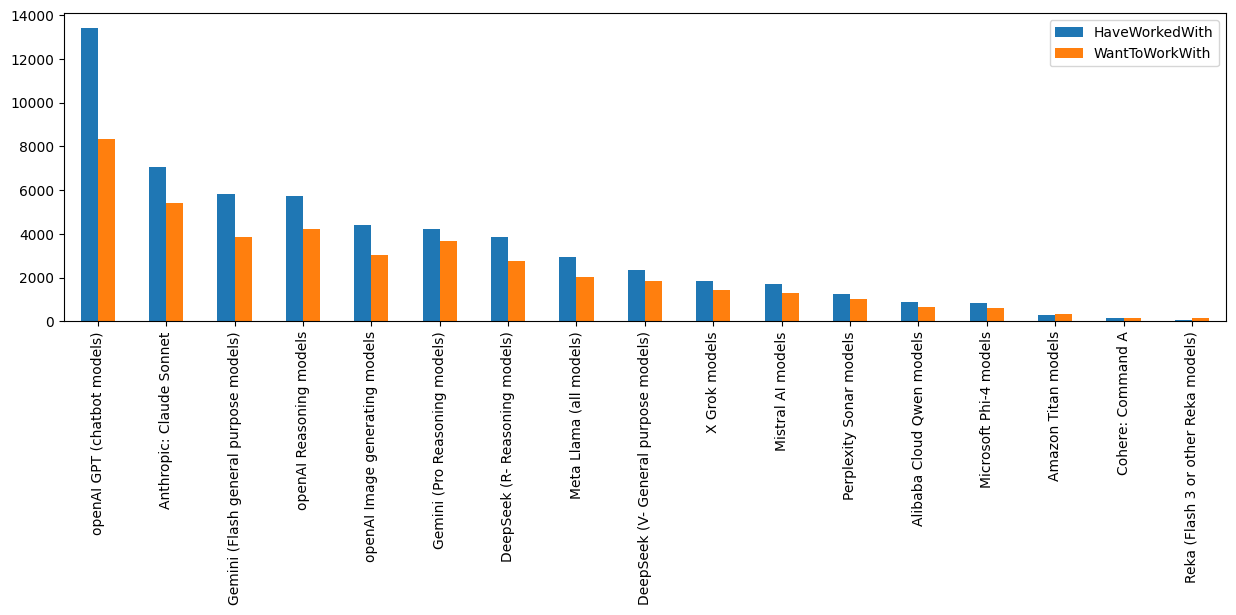

In [62]:
#AIModelsHaveWorkedWith, AIModelsWantToWorkWith,
vc_o = df['AIModelsHaveWorkedWith'].str.split(';').explode().value_counts()
vc_n = df['AIModelsWantToWorkWith'].str.split(';').explode().value_counts()
df_aimodels = pd.concat([vc_o.rename("HaveWorkedWith"),vc_n.rename("WantToWorkWith")],axis=1)
df_aimodels.plot(kind='bar',figsize=(15,4))


<Axes: >

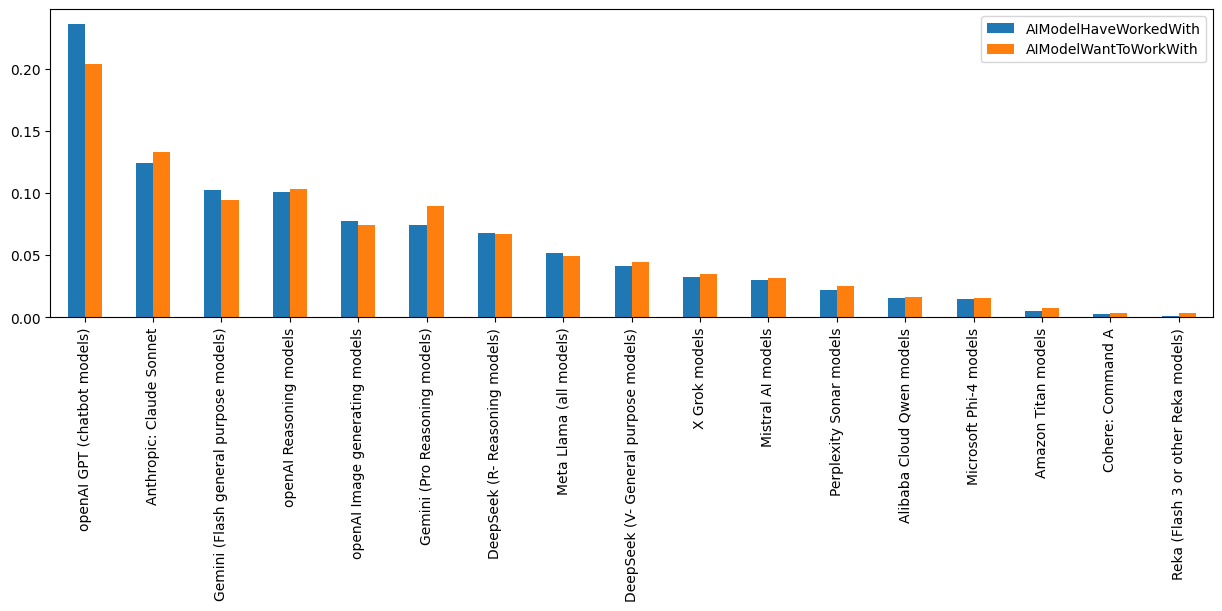

In [63]:
vc_orate = vc_o / vc_o.sum()
vc_nrate = vc_n / vc_n.sum()
df_aimodels_rate = pd.concat([vc_orate.rename("AIModelHaveWorkedWith"),vc_nrate.rename("AIModelWantToWorkWith")],axis=1)
df_aimodels_rate.plot(kind='bar',figsize=(15,4))

In [64]:
#AISelect
vc = df['AISelect'].value_counts()
respondents = df['AISelect'].notnull().sum()
participants = df['AISelect'].shape[0]
percentage(vc)
curnum_users = vc[['Yes, I use AI tools daily','Yes, I use AI tools weekly','Yes, I use AI tools monthly or infrequently']].sum()
print('Number of currently using users: ', curnum_users)
print(f"Ratio of using users to respondents: {curnum_users / respondents * 100:.2f}%")
print(f"Ratio of using users to participants: {curnum_users / participants * 100:.2f}%")

Yes, I use AI tools daily                        15,883(47.10%)
Yes, I use AI tools weekly                        5,958(17.67%)
No, and I don't plan to                           5,454(16.17%)
Yes, I use AI tools monthly or infrequently       4,628(13.72%)
No, but I plan to soon                            1,797( 5.33%)
Number of currently using users:  26469
Ratio of using users to respondents: 78.50%
Ratio of using users to participants: 53.81%


<Axes: title={'center': 'Ratio of using users to respondents'}>

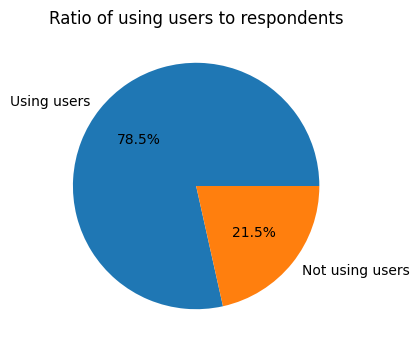

In [65]:
s_ynuse = pd.Series([curnum_users/respondents*100,100-(curnum_users/respondents*100)],index=['Using users','Not using users'])
s_ynuse.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='Ratio of using users to respondents')

In [66]:
#AISent
vc = df['AISent'].value_counts()
respondents = df['AISelect'].notnull().sum()
participants = df['AISelect'].shape[0]
percentage(vc)
print('Number of respondents: ', respondents)
print('Number of participants: ', participants)
favorite_users = vc[['Favorable','Very favorable']].sum()
print('Number of favorite users: ', favorite_users)
print(f"Ratio of favorite users to respondents: {favorite_users / respondents * 100:.2f}%")
print(f"Ratio of favorite users to participants: {favorite_users / participants * 100:.2f}%")
unfavorable_users = vc[['Unfavorable','Very unfavorable']].sum()
print('Number of unfavorable users: ', unfavorable_users)
print(f"Ratio of unfavorable users to respondents: {unfavorable_users / respondents * 100:.2f}%")
print(f"Ratio of unfavorable users to participants: {unfavorable_users / participants * 100:.2f}%")

Favorable             12,311(36.79%)
Very favorable         7,677(22.94%)
Indifferent            5,880(17.57%)
Unfavorable            3,621(10.82%)
Very unfavorable       3,219( 9.62%)
Unsure                   759( 2.27%)
Number of respondents:  33720
Number of participants:  49191
Number of favorite users:  19988
Ratio of favorite users to respondents: 59.28%
Ratio of favorite users to participants: 40.63%
Number of unfavorable users:  6840
Ratio of unfavorable users to respondents: 20.28%
Ratio of unfavorable users to participants: 13.90%


<Axes: title={'center': 'Ratio of favoriteness'}>

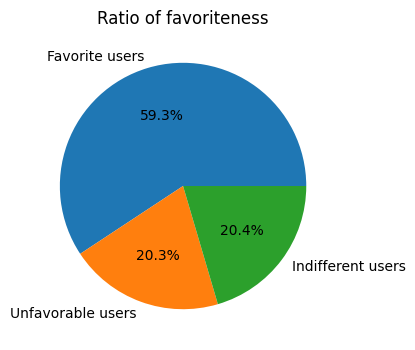

In [67]:
s_ynfavorite = pd.Series([favorite_users/respondents*100,
                          unfavorable_users/respondents*100,
                          (respondents-favorite_users-unfavorable_users)/respondents*100],index=['Favorite users','Unfavorable users','Indifferent users'])
s_ynfavorite.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='Ratio of favoriteness')

In [68]:
#AIAcc
vc = df['AIAcc'].value_counts()
respondents = df['AIAcc'].notnull().sum()
participants = df['AIAcc'].shape[0]
percentage(vc)
trust_users = vc[['Highly trust','Somewhat trust']].sum()
print('Number of trust users: ', trust_users)
print(f"Ratio of trust users to respondents: {trust_users / respondents * 100:.2f}%")
print(f"Ratio of trust users to participants: {trust_users / participants * 100:.2f}%")
distrust_users = vc[['Highly distrust','Somewhat distrust']].sum()
print('Number of distrust users: ', distrust_users)
print(f"Ratio of distrust users to respondents: {distrust_users / respondents * 100:.2f}%")
print(f"Ratio of distrust users to participants: {distrust_users / participants * 100:.2f}%")

Somewhat trust                   9,869(29.64%)
Somewhat distrust                8,685(26.08%)
Neither trust nor distrust       7,162(21.51%)
Highly distrust                  6,533(19.62%)
Highly trust                     1,048( 3.15%)
Number of trust users:  10917
Ratio of trust users to respondents: 32.79%
Ratio of trust users to participants: 22.19%
Number of distrust users:  15218
Ratio of distrust users to respondents: 45.70%
Ratio of distrust users to participants: 30.94%


<Axes: title={'center': 'Ratio of accuracy trustfulness'}>

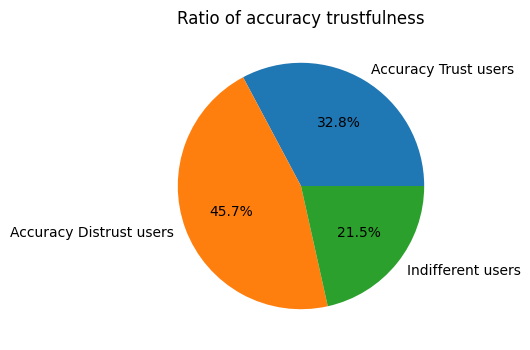

In [69]:
s_ynaccuracy = pd.Series([trust_users/respondents*100,
                          distrust_users/respondents*100,
                          (respondents-trust_users-distrust_users)/respondents*100],index=['Accuracy Trust users','Accuracy Distrust users','Indifferent users'])
s_ynaccuracy.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='Ratio of accuracy trustfulness')

In [70]:
#AIComplex
vc = df['AIComplex'].value_counts()
respondents = df['AIComplex'].notnull().sum()
participants = df['AIComplex'].shape[0]
percentage(vc)
trust_users = vc[['Very well at handling complex tasks','Good, but not great at handling complex tasks']].sum()
print('Number of trust users: ', trust_users)
print(f"Ratio of trust users to respondents: {trust_users / respondents * 100:.2f}%")
print(f"Ratio of trust users to participants: {trust_users / participants * 100:.2f}%")
distrust_users = vc[['Bad at handling complex tasks','Very poor at handling complex tasks']].sum()
print('Number of distrust users: ', distrust_users)
print(f"Ratio of distrust users to respondents: {distrust_users / respondents * 100:.2f}%")
print(f"Ratio of distrust users to participants: {distrust_users / participants * 100:.2f}%")

Good, but not great at handling complex tasks               8,384(25.19%)
Bad at handling complex tasks                               7,328(22.02%)
Very poor at handling complex tasks                         5,844(17.56%)
I don't use AI tools for complex tasks / I don't know       5,582(16.77%)
Neither good or bad at handling complex tasks               4,688(14.09%)
Very well at handling complex tasks                         1,457( 4.38%)
Number of trust users:  9841
Ratio of trust users to respondents: 29.57%
Ratio of trust users to participants: 20.01%
Number of distrust users:  13172
Ratio of distrust users to respondents: 39.58%
Ratio of distrust users to participants: 26.78%


<Axes: title={'center': 'Ratio of complexity trustfulness'}>

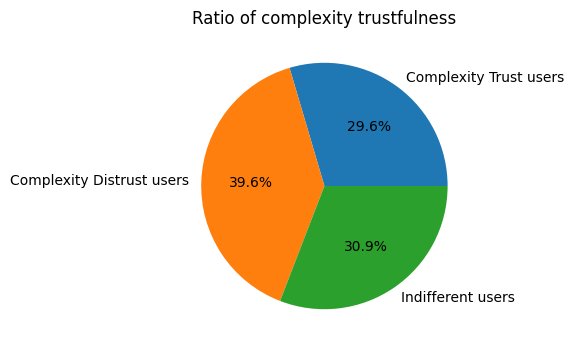

In [71]:
s_yncomplexity = pd.Series([trust_users/respondents*100,
                          distrust_users/respondents*100,
                          (respondents-trust_users-distrust_users)/respondents*100],index=['Complexity Trust users','Complexity Distrust users','Indifferent users'])
s_yncomplexity.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='Ratio of complexity trustfulness')

Writing code                               12,408(14.04%)
Search for answers                         11,729(13.27%)
Learning new concepts or technologies       9,962(11.27%)
Debugging or fixing code                    9,900(11.20%)
Learning about a codebase                   6,874( 7.78%)
Documenting code                            6,361( 7.20%)
Generating content or synthetic data        6,025( 6.82%)
Testing code                                5,786( 6.55%)
Creating or maintaining documentation       5,740( 6.50%)
Committing and reviewing code               4,747( 5.37%)
Project planning                            3,595( 4.07%)
Predictive analytics                        2,674( 3.03%)
Deployment and monitoring                   2,197( 2.49%)
Other (write in):                             369( 0.42%)


<Axes: title={'center': 'Ratio of functionality usage'}>

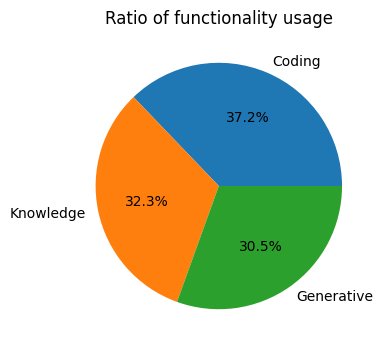

In [72]:
#AIToolCurrently partially AI
vc = df['AIToolCurrently partially AI'].str.split(';').explode().value_counts()
respondents = df['AIToolCurrently partially AI'].notnull().sum()
participants = df['AIToolCurrently partially AI'].shape[0]
percentage(vc)
f_coding = vc[['Writing code','Debugging or fixing code','Testing code','Committing and reviewing code']].sum()
f_knowledge = vc[['Search for answers','Learning new concepts or technologies','Learning about a codebase']].sum()
f_generative = vc.sum() - f_coding - f_knowledge
s_functionality = pd.Series([f_coding/respondents*100,
                             f_knowledge/respondents*100,
                             f_generative/respondents*100],index=['Coding','Knowledge','Generative'])
s_functionality.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='Ratio of functionality usage')

In [73]:
#AIToolDon't plan to use AI for this task
df["AIToolDon't plan to use AI for this task"].str.split(';').explode().value_counts()

AIToolDon't plan to use AI for this task
Deployment and monitoring                19242
Project planning                         17566
Predictive analytics                     16639
Committing and reviewing code            14892
Testing code                             11196
Creating or maintaining documentation    10054
Learning about a codebase                 9999
Documenting code                          9756
Generating content or synthetic data      9681
Debugging or fixing code                  9226
Learning new concepts or technologies     8182
Writing code                              7323
Search for answers                        4958
Other (write in):                         2898
Name: count, dtype: int64

In [74]:
#AIToolPlan to partially use AI
df['AIToolPlan to partially use AI'].str.split(';').explode().value_counts()

AIToolPlan to partially use AI
Learning about a codebase                7873
Testing code                             7820
Creating or maintaining documentation    7328
Writing code                             7301
Committing and reviewing code            7080
Debugging or fixing code                 6961
Documenting code                         6877
Generating content or synthetic data     6317
Learning new concepts or technologies    6306
Predictive analytics                     5645
Deployment and monitoring                5644
Project planning                         5602
Search for answers                       5409
Other (write in):                         331
Name: count, dtype: int64

In [75]:
#AIToolPlan to mostly use AI
df['AIToolPlan to mostly use AI'].str.split(';').explode().value_counts()


AIToolPlan to mostly use AI
Creating or maintaining documentation    4070
Generating content or synthetic data     3712
Documenting code                         3674
Testing code                             3312
Learning about a codebase                2961
Predictive analytics                     2946
Search for answers                       2212
Committing and reviewing code            2090
Learning new concepts or technologies    2018
Deployment and monitoring                1936
Debugging or fixing code                 1906
Project planning                         1834
Writing code                             1598
Other (write in):                         253
Name: count, dtype: int64

In [76]:
#AIToolCurrently mostly AI
df['AIToolCurrently mostly AI'].str.split(';').explode().value_counts()

AIToolCurrently mostly AI
Search for answers                       6070
Generating content or synthetic data     4018
Learning new concepts or technologies    3714
Documenting code                         3454
Creating or maintaining documentation    2783
Learning about a codebase                2338
Debugging or fixing code                 2318
Testing code                             2009
Writing code                             1900
Predictive analytics                     1230
Project planning                         1215
Committing and reviewing code            1139
Deployment and monitoring                 693
Other (write in):                         345
Name: count, dtype: int64

AI solutions that are almost right, but not quite         20,806(35.35%)
Debugging AI-generated code is more time-consuming        14,262(24.23%)
I don’t use AI tools regularly                             7,413(12.59%)
I’ve become less confident in my own problem-solving       6,323(10.74%)
It’s hard to understand how or why the code works          5,147( 8.74%)
Other (write in):                                          3,659( 6.22%)
I haven’t encountered any problems                         1,247( 2.12%)
1247 46538 11072


<Axes: title={'center': 'Ratio of frustration'}>

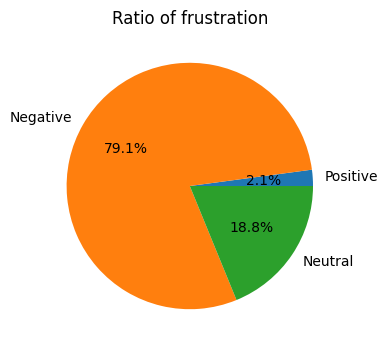

In [77]:
#AIFrustration, AIExplain
vc = df['AIFrustration'].str.split(';').explode().value_counts()
percentage(vc)
pos_ans = vc[['I haven’t encountered any problems']].sum()
neg_ans = vc[["AI solutions that are almost right, but not quite",
"Debugging AI-generated code is more time-consuming",
"I’ve become less confident in my own problem-solving",
"It’s hard to understand how or why the code works"]].sum()
mid_ans = vc.sum() - pos_ans - neg_ans
print(pos_ans,neg_ans,mid_ans)
s_frustration = pd.Series([pos_ans/respondents*100,
                           neg_ans/respondents*100,
                           mid_ans/respondents*100],index=['Positive','Negative','Neutral'])
s_frustration.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='Ratio of frustration')

In [78]:
def sc_group(vc, c):
    res = vc[vc.index.str.startswith(c)|vc.index.str.startswith(c.upper())]
    return res.sum(), res

In [79]:
#AIExplain, vibe coding
vc = df['AIExplain'].str.split(';').explode().value_counts()
print("Total number of responses: ",vc.sum())
res_y = vc[vc.index.str.startswith('Y')|vc.index.str.startswith('y')]
print('Y or y responses:', res_y.sum())
res_n = vc[vc.index.str.startswith('N')|vc.index.str.startswith('n')]
print('N or n responses:', res_n.sum())
res_s = vc[vc.index.str.startswith('S')|vc.index.str.startswith('s')]
print('S or s responses:', res_s.sum())
res_s
res = vc[vc.index.str.startswith('F')|vc.index.str.startswith('f')]
print(res.sum())
res
n, res = sc_group(vc, 'G')
print('G or g responses:', n)
res

Total number of responses:  26746
Y or y responses: 2951
N or n responses: 17768
S or s responses: 569
324
G or g responses: 63


AIExplain
God no                                                                                                                                                                                                                                                                                  10
God no.                                                                                                                                                                                                                                                                                  5
God, no                                                                                                                                                                                                                                                                                  2
Good god no.                                                                                                                                 

AIAgents
No, and I don't plan to                                  12082
No, but I plan to                                         5561
Yes, I use AI agents at work daily                        4509
No, I use AI exclusively in copilot/autocomplete mode     4401
Yes, I use AI agents at work weekly                       2868
Yes, I use AI agents at work monthly or infrequently      2498
Name: count, dtype: int64
Number of positive responses:  9875
Number of negative responses:  22044


<Axes: title={'center': 'AIAgents: Ratio of positive and negative responses'}>

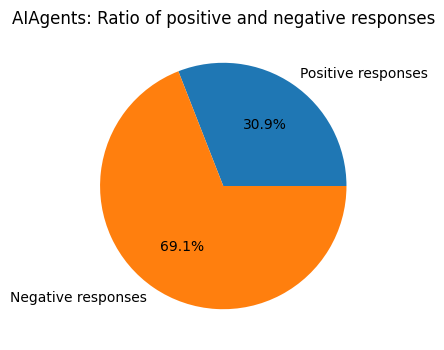

In [80]:
#AIAgents
print(df['AIAgents'].str.split(';').explode().value_counts())
agent_pos = df.loc[df['AIAgents'].str.startswith('Yes',na=False),'AIAgents'].value_counts()
agent_neg = df.loc[df['AIAgents'].str.startswith('No',na=False),'AIAgents'].value_counts()
print('Number of positive responses: ', agent_pos.sum())
print('Number of negative responses: ', agent_neg.sum())
pn_s = pd.Series([agent_pos.sum(), agent_neg.sum()],index=['Positive responses','Negative responses'])
pn_s.plot(kind='pie',autopct='%1.1f%%',figsize=(4,4),title='AIAgents: Ratio of positive and negative responses')

In [81]:
df['AIAgent_Uses'].str.split(';').explode().value_counts()


AIAgent_Uses
Software engineering                  10294
Data and analytics                     3066
IT operations                          2216
Business process automation            2165
Decision intelligence                  1385
Customer service support               1383
Marketing                              1060
Cybersecurity                           908
Robotics                                485
Other Industry purpose (write in):      266
Name: count, dtype: int64

In [82]:
df['AgentUsesGeneral'].str.split(';').explode().value_counts()

AgentUsesGeneral
Language processing                          2848
Integration with external agents and APIs    2224
MCP servers                                  2000
Agent/multi-agent orchestration              1629
Vector databases for AI applications         1397
Multi-platform search enablement             1128
Personalized agent creation                  1065
Other specific task (write in):               173
Name: count, dtype: int64

In [83]:
agent_impact_cols = [
    'AIAgentImpactSomewhat agree',
    'AIAgentImpactNeutral',
    'AIAgentImpactSomewhat disagree',
    'AIAgentImpactStrongly agree',
    'AIAgentImpactStrongly disagree'
]
agent_impact_rows = [
    'AI agents have increased my productivity.',
    'AI agents have helped me automate repetitive tasks.',
    'AI agents have improved the quality of my code.',
    'AI agents have accelerated my learning about new technologies or codebases.',
    'AI agents have helped me solve complex problems more effectively.',
    'AI agents have reduced the time spent on specific development tasks.',
    'AI agents have improved collaboration within my team.',
    'Write in the most significant benefit if not listed above.'
]


<Axes: ylabel='Item'>

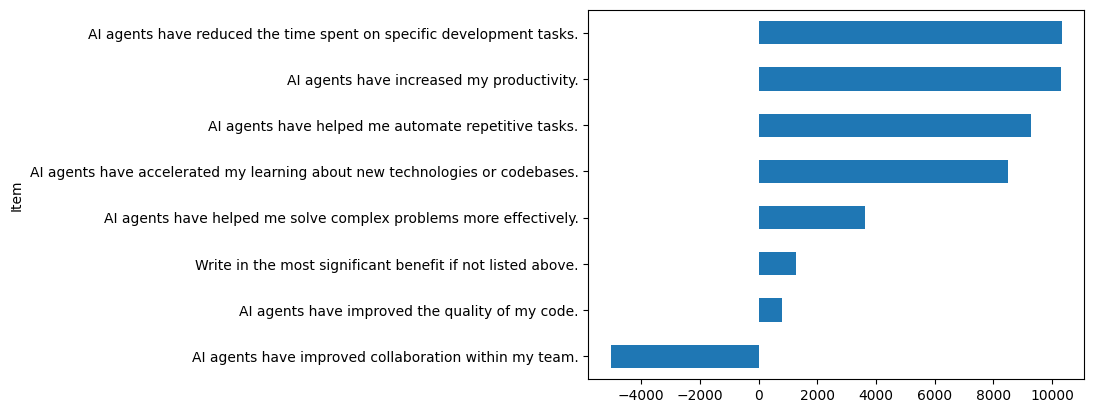

In [84]:
#agent_impact_cols
neg2 = df['AIAgentImpactStrongly disagree'].str.split(';').explode().value_counts(sort=False).sort_index()
neg1 = df['AIAgentImpactSomewhat disagree'].str.split(';').explode().value_counts(sort=False).sort_index()
neutral = df['AIAgentImpactNeutral'].str.split(';').explode().value_counts(sort=False).sort_index()
pos1 = df['AIAgentImpactSomewhat agree'].str.split(';').explode().value_counts(sort=False).sort_index()
pos2 = df['AIAgentImpactStrongly agree'].str.split(';').explode().value_counts(sort=False).sort_index()
itm0 =neg2[agent_impact_rows[0]]*(-2) + neg1[agent_impact_rows[0]]*(-1) + neutral[agent_impact_rows[0]]*0 + pos1[agent_impact_rows[0]]*1 + pos2[agent_impact_rows[0]]*2
itm1 = neg2[agent_impact_rows[1]]*(-2) + neg1[agent_impact_rows[1]]*(-1) + neutral[agent_impact_rows[1]]*0 + pos1[agent_impact_rows[1]]*1 + pos2[agent_impact_rows[1]]*2
itm2 = neg2[agent_impact_rows[2]]*(-2) + neg1[agent_impact_rows[2]]*(-1) + neutral[agent_impact_rows[2]]*0 + pos1[agent_impact_rows[2]]*1 + pos2[agent_impact_rows[2]]*2
itm3 = neg2[agent_impact_rows[3]]*(-2) + neg1[agent_impact_rows[3]]*(-1) + neutral[agent_impact_rows[3]]*0 + pos1[agent_impact_rows[3]]*1 + pos2[agent_impact_rows[3]]*2
itm4 = neg2[agent_impact_rows[4]]*(-2) + neg1[agent_impact_rows[4]]*(-1) + neutral[agent_impact_rows[4]]*0 + pos1[agent_impact_rows[4]]*1 + pos2[agent_impact_rows[4]]*2
itm5 = neg2[agent_impact_rows[5]]*(-2) + neg1[agent_impact_rows[5]]*(-1) + neutral[agent_impact_rows[5]]*0 + pos1[agent_impact_rows[5]]*1 + pos2[agent_impact_rows[5]]*2
itm6 = neg2[agent_impact_rows[6]]*(-2) + neg1[agent_impact_rows[6]]*(-1) + neutral[agent_impact_rows[6]]*0 + pos1[agent_impact_rows[6]]*1 + pos2[agent_impact_rows[6]]*2
itm7 = neg2[agent_impact_rows[7]]*(-2) + neg1[agent_impact_rows[7]]*(-1) + neutral[agent_impact_rows[7]]*0 + pos1[agent_impact_rows[7]]*1 + pos2[agent_impact_rows[7]]*2
item_scores = [itm0, itm1, itm2, itm3, itm4, itm5, itm6, itm7]
item_scores_df = pd.DataFrame({'Item': agent_impact_rows, 'Score': item_scores}).sort_values(by='Score', ascending=True)
item_scores_df.plot(x='Item', y='Score', kind='barh', legend=False)

In [85]:
challenges_rows = [
    "I am concerned about the accuracy of the information provided by AI agents.",
    "I have concerns about the security and privacy of data when using AI agents.",
    "Integrating AI agents with my existing tools and workflows can be difficult.",
    "It takes significant time and effort to learn how to use AI agents effectively.",
    "My company's IT and/or InfoSec teams have strict rules that do not allow me to use AI agent tools or platforms",
    "The cost of using certain AI agent platforms is a barrier.",
    "Write in the most significant challenge if not listed above:"
]



[np.int64(40245),
 np.int64(36560),
 np.int64(12025),
 np.int64(7731),
 np.int64(-6996),
 np.int64(16687),
 np.int64(4049)]

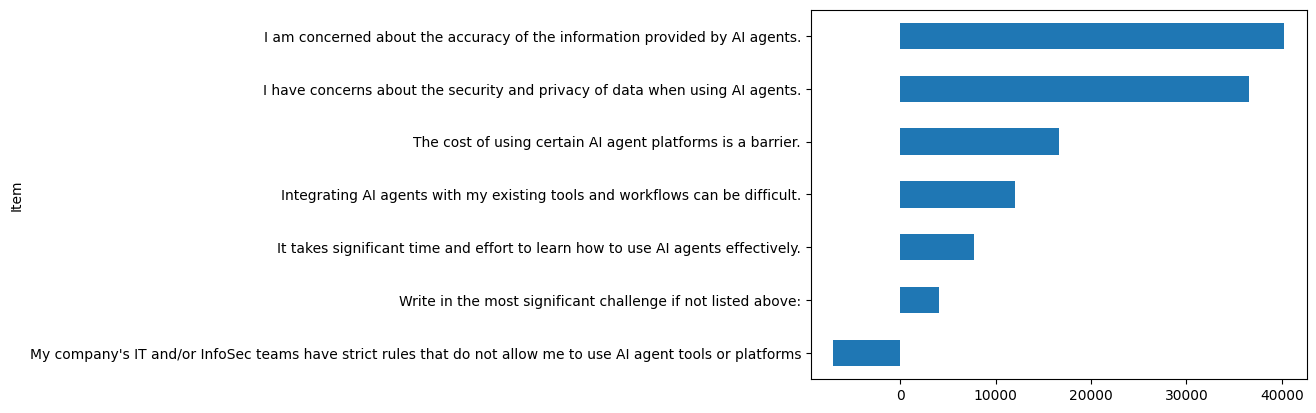

In [86]:
#AIAgentChallenges
df['AIAgentChallengesStrongly disagree'].str.split(';').explode().value_counts(sort=False).sort_index()
df['AIAgentChallengesSomewhat disagree'].str.split(';').explode().value_counts(sort=False).sort_index()
df['AIAgentChallengesNeutral'].str.split(';').explode().value_counts(sort=False).sort_index()
df['AIAgentChallengesSomewhat agree'].str.split(';').explode().value_counts(sort=False).sort_index()
df['AIAgentChallengesStrongly agree'].str.split(';').explode().value_counts(sort=False).sort_index()
neg2 = df['AIAgentChallengesStrongly disagree'].str.split(';').explode().value_counts(sort=False).sort_index()
neg1 = df['AIAgentChallengesSomewhat disagree'].str.split(';').explode().value_counts(sort=False).sort_index()
neutral = df['AIAgentChallengesNeutral'].str.split(';').explode().value_counts(sort=False).sort_index()
pos1 = df['AIAgentChallengesSomewhat agree'].str.split(';').explode().value_counts(sort=False).sort_index()
pos2 = df['AIAgentChallengesStrongly agree'].str.split(';').explode().value_counts(sort=False).sort_index()
itm0 = neg2[challenges_rows[0]]*(-2) + neg1[challenges_rows[0]]*(-1) + neutral[challenges_rows[0]]*0 + pos1[challenges_rows[0]]*1 + pos2[challenges_rows[0]]*2
itm1 = neg2[challenges_rows[1]]*(-2) + neg1[challenges_rows[1]]*(-1) + neutral[challenges_rows[1]]*0 + pos1[challenges_rows[1]]*1 + pos2[challenges_rows[1]]*2
itm2 = neg2[challenges_rows[2]]*(-2) + neg1[challenges_rows[2]]*(-1) + neutral[challenges_rows[2]]*0 + pos1[challenges_rows[2]]*1 + pos2[challenges_rows[2]]*2
itm3 = neg2[challenges_rows[3]]*(-2) + neg1[challenges_rows[3]]*(-1) + neutral[challenges_rows[3]]*0 + pos1[challenges_rows[3]]*1 + pos2[challenges_rows[3]]*2
itm4 = neg2[challenges_rows[4]]*(-2) + neg1[challenges_rows[4]]*(-1) + neutral[challenges_rows[4]]*0 + pos1[challenges_rows[4]]*1 + pos2[challenges_rows[4]]*2
itm5 = neg2[challenges_rows[5]]*(-2) + neg1[challenges_rows[5]]*(-1) + neutral[challenges_rows[5]]*0 + pos1[challenges_rows[5]]*1 + pos2[challenges_rows[5]]*2
itm6 = neg2[challenges_rows[6]]*(-2) + neg1[challenges_rows[6]]*(-1) + neutral[challenges_rows[6]]*0 + pos1[challenges_rows[6]]*1 + pos2[challenges_rows[6]]*2
item_scores = [itm0, itm1, itm2, itm3, itm4, itm5, itm6]
item_scores_df = pd.DataFrame({'Item': challenges_rows, 'Score': item_scores}).sort_values(by='Score', ascending=True)
item_scores_df.plot(x='Item', y='Score', kind='barh', legend=False)
item_scores

<Axes: ylabel='AIAgentKnowledge'>

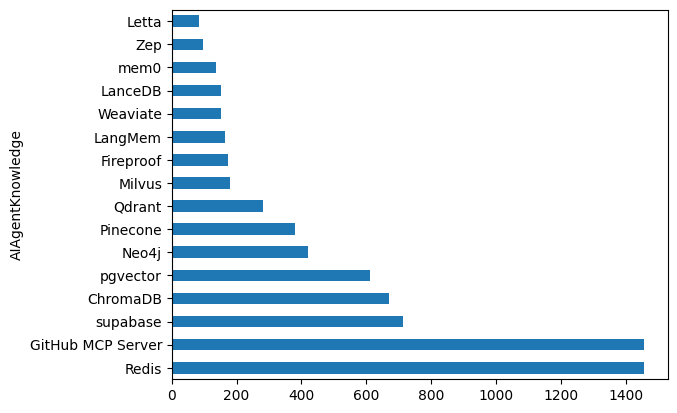

In [87]:
#AIAgentKnowledge
notnacc = df['AIAgentKnowledge'].notnull().sum()
notnacc
df['AIAgentKnowledge'].str.split(';').explode().value_counts().plot(kind='barh', legend=False)

In [88]:
#AIAgentKnowWrite
df['AIAgentKnowWrite'].str.split(';').explode().value_counts().head(25)

AIAgentKnowWrite
Copilot            15
n8n                15
ChatGPT            13
Cursor             13
Junie              12
no                  9
Claude Code         8
LangChain           7
Github Copilot      7
No                  7
cursor              7
Langchain           7
copilot             7
GitHub Copilot      6
custom              6
1                   5
chatgpt             5
yes                 4
langchain           4
Azure AI Search     4
Claude              4
Cline               4
Tidewave            4
Augment             3
Gemini              3
Name: count, dtype: int64

In [89]:
#AIAgentOrchestration
df['AIAgentOrchestration'].str.split(';').explode().value_counts()

AIAgentOrchestration
Ollama                   1921
LangChain                1239
LangGraph                 608
Vertex AI                 570
Amazon Bedrock Agents     546
OpenRouter                505
Llama Index               502
AutoGen (Microsoft)       454
Zapier                    443
CrewAI                    284
Semantic Kernel           225
IBM watsonx.ai            216
Haystack                  165
Smolagents                140
Agno                      127
phidata                    80
Smol-AGI                   73
Martian                    66
lyzr                       58
Name: count, dtype: int64

In [90]:
#AIAgentOrchWrite
df['AIAgentOrchWrite'].str.split(';').explode().value_counts().head(25)

AIAgentOrchWrite
n8n                28
Copilot            12
No                  8
no                  8
Cursor              7
Junie               7
none                7
Pydantic AI         5
copilot             5
ChatGPT             5
Spring AI           5
Claude Code         4
Google ADK          4
Github Copilot      4
N8N                 4
llama.cpp           4
N8n                 3
LM Studio           3
Mastra              3
GitHub Copilot      3
Gemini              3
JetBrains Junie     3
Zed                 3
Azure               3
Amazon Q            3
Name: count, dtype: int64

In [91]:
#AIAgentObserveSecure
df['AIAgentObserveSecure'].str.split(';').explode().value_counts()

AIAgentObserveSecure
Grafana + Prometheus                    1156
Sentry                                   857
Snyk                                     491
New Relic                                351
LangSmith                                337
Honeycomb                                240
Langfuse                                 239
Wiz                                      186
Galileo                                  168
Adversarial Robustness Toolbox (ART)     148
Protect AI                               136
Vectra AI                                119
arize                                    100
helicone                                  87
Metero                                    74
opik                                      63
Name: count, dtype: int64

In [92]:
#AIAgentObsWrite
df['AIAgentObsWrite'].str.split(';').explode().value_counts().head(25)

AIAgentObsWrite
no                                     13
Datadog                                12
none                                    7
Dynatrace                               7
Copilot                                 5
No                                      5
1                                       4
copilot                                 4
-                                       3
0                                       3
datadog                                 3
ChatGPT                                 3
n8n                                     3
AgentOps                                3
chatgpt                                 3
ChatGPT, Copilot                        2
Cloudwatch                              2
wandb                                   2
Logfire                                 2
DataDog                                 2
Github Copilot                          2
coroot, opentelemetry, fluvio           1
Observe                                 1
CoPilot           

In [93]:
#AIAgentExternal
df['AIAgentExternal'].str.split(';').explode().value_counts()

AIAgentExternal
ChatGPT                           6807
GitHub Copilot                    5656
Google Gemini                     3952
Claude Code                       3398
Microsoft Copilot                 2603
Perplexity                        1353
v0.dev                             756
Bolt.new                           542
Lovable.dev                        476
AgentGPT                           419
Tabnine                            418
Replit                             416
Auto-GPT                           389
Amazon Codewhisperer               322
Blackbox AI                        288
Roo code (Roo-Cline)               282
Cody                               255
Devin AI                           228
Glean (Enterprise Agents)          110
OpenHands (formerly OpenDevin)      86
Name: count, dtype: int64

In [94]:
#AIAgentExtWrite
df['AIAgentExtWrite'].str.split(';').explode().value_counts().head(25)

AIAgentExtWrite
Cursor             106
Junie               39
Grok                29
cursor              23
Windsurf            23
DeepSeek            19
Cline               17
Augment             13
Deepseek            12
Zed                 11
JetBrains Junie     10
deepseek             9
aider                9
Amazon Q             9
windsurf             8
Jetbrains Junie      8
Aider                8
Augment Code         7
Jetbrains AI         7
no                   6
grok                 5
GitLab Duo           5
JetBrains AI         5
mistral              4
Supermaven           4
Name: count, dtype: int64

In [95]:
#AIHuman
df['AIHuman'].str.split(';').explode().value_counts()

AIHuman
When I don’t trust AI’s answers                        21980
When I have ethical or security concerns about code    18010
When I want to fully understand something              17885
When I want to learn best practices                    16962
When I’m stuck and can’t explain the problem           15938
When I need help fixing complex or unfamiliar code     14537
When I want to compare different solutions             12886
When I need quick help troubleshooting                  8014
Other (please specify):                                 1791
I don’t think I’ll need help from people anymore        1247
Name: count, dtype: int64

In [103]:
#AIOpen
df['AIOpen'].notnull().sum()
df['AIOpen']

0                    Troubleshooting, profiling, debugging
1                                All skills. AI is a flop.
2        Understand how things actually work, problem s...
3                                                      NaN
4        critical thinking, the skill to define the tas...
5             designing the architecture in the new domain
6                                                      NaN
7                                Innovation, system design
8                                                      NaN
9                                                      NaN
10       Code writing. I know this sounds weird but you...
11                                                     NaN
12                                                     NaN
13                                                     NaN
14                                      senior development
15                                                       5
16       All the ones that INTELLIGENT programmers curr.

<Axes: title={'center': 'ConvertedCompYearly by Country'}>

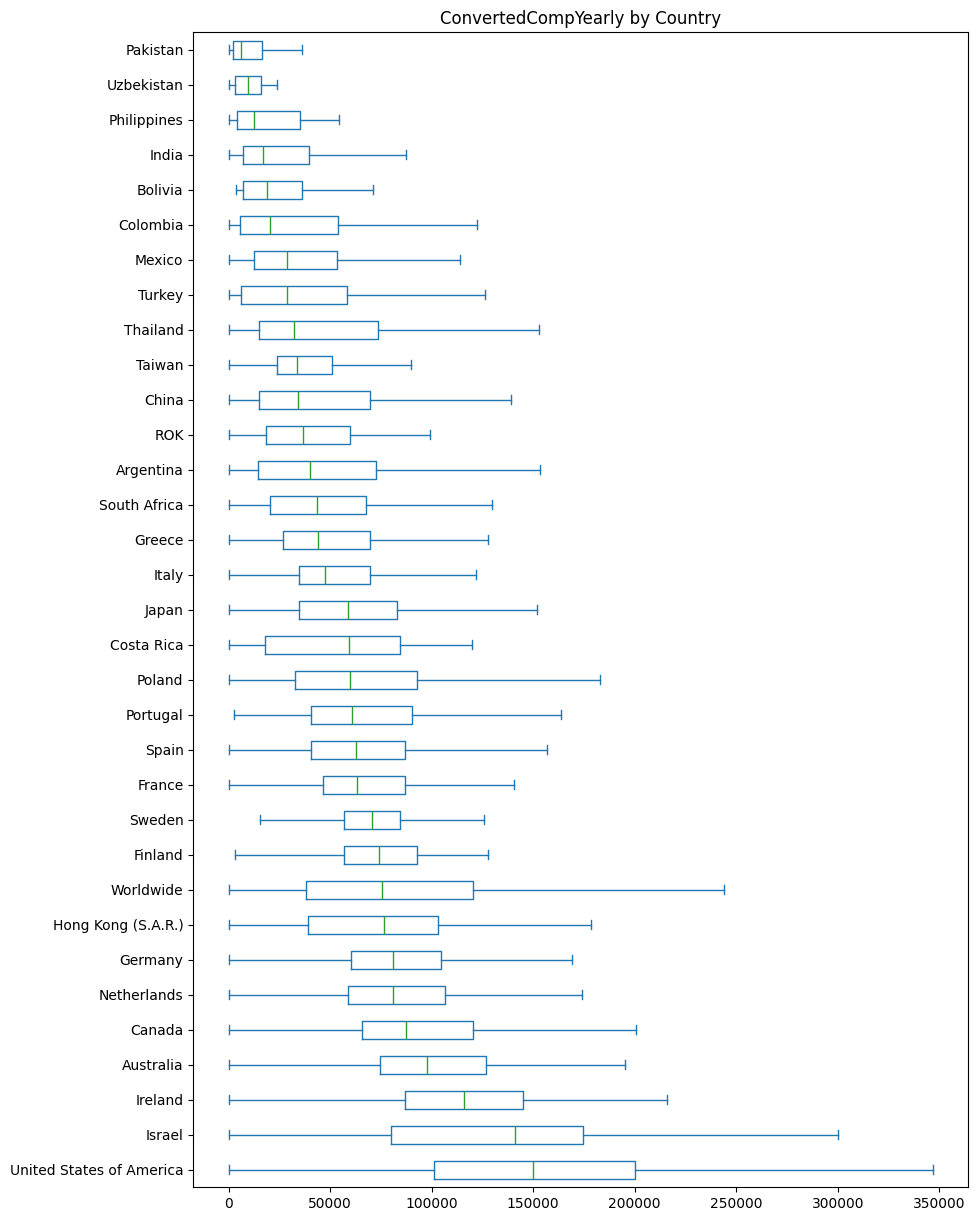

In [97]:
countries = ['Argentina','Australia','Bolivia','Canada','China','Colombia','Costa Rica','Finland','France','Germany','Greece','Hong Kong (S.A.R.)','India','Ireland','Israel',
'Italy','Japan','Mexico','Netherlands','Pakistan','Philippines','Poland','Portugal','South Africa','Spain',
'Sweden','Taiwan','Thailand','Turkey','United States of America','Uzbekistan']
#countries = ['United States of America', 'Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland', 'France', 'Canada', 'Ukraine', 'Poland', 'Netherlands', 'Italy', 'Brazil', 'Australia', 'Spain', 'Sweden', 'Switzerland', 'Czech Republic', 'Austria', 'Romania', 'Belgium', 'Denmark', 'Israel', 'Turkey', 'Mexico', 'Portugal', 'China', 'New Zealand', 'Finland', 'South Africa', 'Greece', 'Bulgaria', 'Pakistan', 'Norway', 'Hungary', 'Argentina', 'Bangladesh', 'Ireland', 'Colombia', 'Russian Federation', 'Nigeria', 'Japan', 'Indonesia', 'Serbia', 'Iran, Islamic Republic of...', 'Kenya', 'Slovakia', 'Viet Nam', 'Philippines', 'Egypt', 'Chile', 'Thailand', 'Taiwan', 'Croatia', 'Lithuania', 'Sri Lanka', 'United Arab Emirates', 'Singapore', 'Nepal', 'Malaysia', 'Slovenia', 'Hong Kong (S.A.R.)', 'Estonia', 'Peru',]
#countries = ['Latvia', 'Morocco', 'Uruguay', 'Algeria', 'Georgia', 'South Korea', 'Venezuela, Bolivarian Republic of...', 'Ghana', 'Tunisia', 'Cyprus', 'Ethiopia', 'Republic of Korea', 'Saudi Arabia', 'Guatemala', 'Jordan', 'Bosnia and Herzegovina', 'Nomadic', 'Kazakhstan', 'Ecuador', 'Uganda', 'Costa Rica', 'Belarus', 'Dominican Republic', 'Armenia', 'Luxembourg', 'Albania', 'Paraguay', 'Republic of North Macedonia', 'Lebanon', 'Malta', 'Yemen', 'Bolivia', 'Azerbaijan', 'Myanmar', 'Uzbekistan', 'Rwanda', 'Montenegro', 'Iceland', 'Cameroon', 'Zambia', 'Afghanistan', 'Zimbabwe', 'Iraq', 'El Salvador', 'Cambodia', 'Honduras', 'Madagascar', 'Syrian Arab Republic', 'Mauritius', 'Isle of Man', 'Panama', 'Kyrgyzstan', 'Moldova', 'Maldives', 'Togo', 'Republic of Moldova', 'Cuba', "Côte d'Ivoire", 'United Republic of Tanzania']
#countries = ['Trinidad and Tobago', 'Democratic Republic of the Congo', 'Namibia', 'Angola', 'Palestine', 'Kuwait', 'Bahrain', 'Nicaragua', 'Andorra', 'North Korea', 'Kosovo', 'Oman', 'Mozambique', 'Qatar', 'Senegal', 'Fiji', 'Congo, Republic of the...', 'Benin', 'Swaziland', 'Somalia', 'Malawi', 'Guyana', 'Jamaica', "Democratic People's Republic of Korea", 'Barbados', 'Papua New Guinea', 'Mongolia', 'Brunei Darussalam', 'Sudan', 'Belize', 'Bhutan', 'Saint Lucia', 'Tajikistan', 'Haiti', 'Botswana', 'Suriname', 'Micronesia, Federated States of...', "Lao People's Democratic Republic", 'Mali', 'Turkmenistan', 'Sierra Leone', 'Antigua and Barbuda', 'Burundi', 'Libyan Arab Jamahiriya', 'Gabon', 'Timor-Leste', 'Mauritania', 'Guinea-Bissau', 'Gambia', 'Niger', 'San Marino', 'Lesotho', 'Djibouti', 'Cape Verde', 'Palau', 'Guinea']

data_dict = {}
for country in countries:
    series = df.loc[df['Country'] == country, 'ConvertedCompYearly'].reset_index(drop=True)
    data_dict[country] = series
data_dict['ROK'] = df.loc[(df['Country'] == 'South Korea')|(df['Country'] == 'Republic of Korea'), 'ConvertedCompYearly'].reset_index(drop=True)
data_dict['Worldwide'] = df['ConvertedCompYearly'].reset_index(drop=True)
countries_df = pd.DataFrame(data_dict)
medians = countries_df.quantile(0.5)
sorted_columns = medians.sort_values(ascending=False).index
countries_df = countries_df[sorted_columns]
countries_df.plot(kind='box', vert=False, showfliers=False, title='ConvertedCompYearly by Country', figsize=(10, 15))

<Axes: >

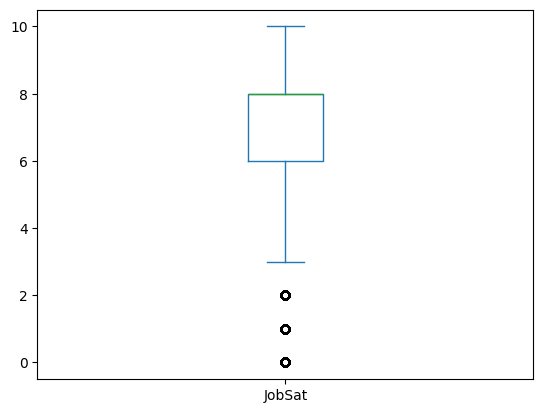

In [98]:
#JobSat
df['JobSat'].describe()
df['JobSat'].plot(kind='box')

### The end of the job